# Pseudo-Labeling Augmentation Experiments

This notebook provides a focused and streamlined workflow for experimenting with the **pseudo-labeling** data augmentation strategy. It is a trimmed-down version of `06_xfg_success_augmented_modelling.ipynb` and contains only the necessary components for this specific task.

**Workflow:**
1. **Data Preparation:** Loads and prepares all necessary data (`fg_all`, `kicker_by_game`, OOF predictions).
2. **Baseline Models:** Fits and saves two baseline models: one for train/test evaluation and another for full in-sample evaluation.
3. **Pseudo-Labeling Playground:** A dedicated cell to define and run a single pseudo-labeling variant on the full in-sample dataset.
4. **Analysis:** Compares the augmented model against the in-sample baseline by plotting prediction distributions and analyzing how individual predictions changed.

In [1]:
# --- Parameters & Setup ---
# Set PROJECT_ROOT to the current working directory with the last path segment removed
PROJECT_ROOT <- sub("[/\\\\][^/\\\\]*$", "", getwd())

data_dir <- file.path(PROJECT_ROOT, 'data')
models_dir <- file.path(PROJECT_ROOT, 'models')
reports_dir <- file.path(PROJECT_ROOT, 'reports')
augmented_dir <- file.path(data_dir, 'augmented')
augmented_models_dir <- file.path(models_dir, 'augmented')
augmented_reports_dir <- file.path(reports_dir, 'xfg_success_augmented')

SEASONS <- 2015:2024
DIST_KNOTS <- c(28, 38, 48, 58)
DIST_BOUNDS <- c(18, 70)
TEST_RATIO <- 0.30
set.seed(202407) # For reproducible train/test split

# --- Library Imports ---
dependencies <- c(
  'dplyr', 'tibble', 'tidyr', 'readr', 'stringr', 'purrr', 'ggplot2',
  'splines', 'splines2', 'glmmTMB', 'pROC', 'rlang', 'scales', 'minqa','lme4','Metrics',
  'ggrepel'
)
installed <- rownames(installed.packages())
for (pkg in dependencies) {
  if (!pkg %in% installed) install.packages(pkg)
  suppressPackageStartupMessages(library(pkg, character.only = TRUE))
}

Warning message:
"package 'glmmTMB' was built under R version 4.5.2"
Warning message:
"package 'pROC' was built under R version 4.5.2"
Warning message:
"package 'minqa' was built under R version 4.5.2"
Warning message:
"package 'lme4' was built under R version 4.5.2"
Warning message:
"package 'Metrics' was built under R version 4.5.2"
Warning message:
"package 'ggrepel' was built under R version 4.5.2"


In [2]:
# ==============================================================================
# 0. Load Libraries & Define Utility Functions
# ==============================================================================
# --- USER PROVIDED UTILITY FUNCTIONS ---

# Distance B-splines using splines2
build_distance_bs <- function(x, knots, bknots, degree = 3, intercept = FALSE) {
  stopifnot(!missing(x), !missing(knots), !missing(bknots))
  if (!requireNamespace("splines2", quietly = TRUE)) stop("Package 'splines2' required")
  bs <- splines2::bSpline(x, knots = knots, Boundary.knots = bknots, degree = degree, intercept = intercept)
  bs <- as.data.frame(bs)
  names(bs) <- paste0("dist_bs_", seq_len(ncol(bs)))
  bs
}

# Loss metrics
brier <- function(y, p) mean((y - p)^2, na.rm = TRUE)
logloss <- function(y, p, eps = 1e-15) -mean(y * log(pmin(pmax(p, eps), 1 - eps)) + (1 - y) * log(1 - pmin(pmax(p, eps), 1 - eps)), na.rm = TRUE)
auc <- function(y, p) {
  keep <- is.finite(p) & is.finite(y)
  if (sum(keep) < 2 || length(unique(y[keep])) < 2) return(NA_real_)
  as.numeric(pROC::auc(y[keep], p[keep], quiet = TRUE))
}

# Safe prediction helper with diagnostics
predict_safe <- function(fit, newdata) {
  if (is.null(fit)) return(rep(NA_real_, nrow(newdata)))
  p_resp <- tryCatch(as.numeric(stats::predict(fit, newdata = newdata, type = "response", allow.new.levels = TRUE)), error = function(e) {
    cat("ERROR in stats::predict:\n")
    cat("Message:", conditionMessage(e), "\n")
    cat("Call:", deparse(conditionCall(e)), "\n")
    NULL
  })
  if (!is.null(p_resp)) return(pmin(pmax(p_resp, 0), 1))
  rep(NA_real_, nrow(newdata))
}

# Pool sparse random effect levels
pool_sparse_levels <- function(train_df, test_df, id_col, min_n = 5L, repl = "REPL", keep_cols = NULL) {
  stopifnot(id_col %in% names(train_df), id_col %in% names(test_df))
  if (!is.null(keep_cols)) {
    train_df <- train_df %>% dplyr::select(dplyr::any_of(keep_cols))
    test_df  <- test_df  %>% dplyr::select(dplyr::any_of(keep_cols))
  }
  tab <- table(train_df[[id_col]])
  keep_levels <- names(tab)[tab >= min_n]
  train_df[[id_col]] <- ifelse(train_df[[id_col]] %in% keep_levels, as.character(train_df[[id_col]]), repl)
  test_df[[id_col]]  <- ifelse(test_df[[id_col]] %in% keep_levels, as.character(test_df[[id_col]]), repl)
  all_levels <- unique(c(train_df[[id_col]], test_df[[id_col]]))
  train_df[[id_col]] <- factor(train_df[[id_col]], levels = all_levels)
  test_df[[id_col]]  <- factor(test_df[[id_col]], levels = all_levels)
  list(train = train_df, test = test_df)
}

# --- 0. Metric Helper Function (Updated with Class Metrics) ---
calc_metrics <- function(y, p, set_name, threshold = 0.5) {
  # specific requires
  requireNamespace("Metrics", quietly = TRUE)
  requireNamespace("pROC", quietly = TRUE)
  
  # Filter for validity
  valid <- is.finite(p) & is.finite(y)
  y <- y[valid]
  p <- p[valid]
  
  # --- Probabilistic Metrics ---
  val_brier <- mean((y - p)^2)
  val_ll    <- Metrics::logLoss(y, p)
  
  # AUC (Safe calculation)
  val_auc <- if (length(unique(y)) < 2) NA_real_ else as.numeric(pROC::auc(y, p, quiet = TRUE))
  
  # Calibration Error (L1)
  cal_df <- tibble::tibble(y = y, p = p) %>%
    dplyr::mutate(bin = dplyr::ntile(p, 10)) %>%
    dplyr::group_by(bin) %>%
    dplyr::summarise(mean_pred = mean(p), mean_obs = mean(y), .groups="drop") %>%
    dplyr::mutate(diff = abs(mean_pred - mean_obs))
  val_calib <- mean(cal_df$diff, na.rm=TRUE)
  
  # --- Classification Metrics (at threshold) ---
  pred_class <- ifelse(p >= threshold, 1, 0)
  
  TP <- sum(y == 1 & pred_class == 1)
  TN <- sum(y == 0 & pred_class == 0)
  FP <- sum(y == 0 & pred_class == 1)
  FN <- sum(y == 1 & pred_class == 0)
  
  val_acc <- (TP + TN) / length(y)
  
  # Handle division by zero for Precision/Recall
  val_prec <- if ((TP + FP) > 0) TP / (TP + FP) else 0.0
  val_rec  <- if ((TP + FN) > 0) TP / (TP + FN) else 0.0
  val_f1   <- if ((val_prec + val_rec) > 0) 2 * (val_prec * val_rec) / (val_prec + val_rec) else 0.0
  
  # Return structured tibble
  tibble::tibble(
    set = set_name,
    brier = val_brier,
    logloss = val_ll,
    auc = val_auc,
    calib_error = val_calib,
    accuracy = val_acc,
    precision = val_prec,
    recall = val_rec,
    f1_score = val_f1
  )
}
ctrl <- glmmTMB::glmmTMBControl(
  optimizer = nlminb, 
  # nlminb understands these specific arguments
  optCtrl = list(iter.max = 1000, eval.max = 1000),
  parallel = 6
)

In [3]:
# ==============================================================================
# 1. Data Loading, Cleaning & Feature Engineering (Consolidated & Complete)
# ==============================================================================

# --- A. Define Paths & Load Raw Data ---
fg_path       <- file.path(data_dir, 'fg_all.csv')
kicker_path   <- file.path(data_dir, 'kicker_by_game.csv')
oof_path      <- file.path(reports_dir, 'attempt_pi', 'attempt_pi_oof_predictions_final.csv')
test_ids_path <- file.path(augmented_dir, 'test_fg_game_ids.csv')

# Fail fast if files are missing
stopifnot(file.exists(fg_path), file.exists(kicker_path), file.exists(oof_path))

fg_all         <- readr::read_csv(fg_path, show_col_types = FALSE)
kicker_by_game <- readr::read_csv(kicker_path, show_col_types = FALSE)
preds_oof      <- readr::read_csv(oof_path, show_col_types = FALSE)

# --- B. Coerce Keys for Consistent Joins ---
fg_all <- fg_all %>% 
  dplyr::mutate(
    season = as.integer(season),
    game_id = as.character(game_id), 
    play_id = as.character(play_id),
    team_for_join = toupper(posteam)
  )

kicker_by_game <- kicker_by_game %>% 
  dplyr::mutate(game_id = as.character(game_id), team = as.character(team))

preds_oof <- preds_oof %>% 
  dplyr::mutate(
    season = as.integer(season),
    game_id = as.character(game_id), 
    play_id = as.character(play_id)
  ) %>%
  dplyr::select(season, game_id, play_id, p_hat_attempt_clipped, w_ipw_final)

# --- C. Filter Universe & Impute Kicker IDs ---
# We keep Attempts (FG/PAT) AND Non-Attempts (Run/Pass/Punt) in the 18-65y range
fg_base <- fg_all %>%
  dplyr::filter(
    as.character(season) %in% as.character(SEASONS),
    play_type_original %in% c('field_goal', 'extra_point', 'pass', 'run', 'punt'),
    kick_distance >= 18 & kick_distance <= 70,
    kick_result != 'blocked' | is.na(kick_result)
  ) %>%
  # Join Kicker IDs (crucial for Non-Attempts)
  dplyr::left_join(
    kicker_by_game %>% dplyr::select(game_id, team, kg_kicker_player_id = kicker_player_id), 
    by = c("game_id" = "game_id", "team_for_join" = "team")
  ) %>%
  dplyr::mutate(
    kicker_player_id = dplyr::coalesce(kicker_player_id, kg_kicker_player_id),
    kicker_player_id = as.factor(ifelse(kicker_player_id == "NA", NA, kicker_player_id)),
    # Define Types
    is_pat = as.integer(play_type_original == 'extra_point'),
    is_fg  = as.integer(play_type_original == 'field_goal'),
    is_non = as.integer(!play_type_original %in% c('field_goal', 'extra_point'))
  ) %>%
  dplyr::select(-kg_kicker_player_id) %>%
  # Join Propensity Scores & Weights
  dplyr::left_join(preds_oof, by = c('season', 'game_id', 'play_id'))

# --- C-2. Impute Age & Experience (Integrated Fix) ---
# 1. Build Reference Table from Actual Attempts (where age/exp exists)
kicker_ref <- fg_base %>%
  dplyr::filter(!is.na(kicker_age), !is.na(kicker_experience)) %>%
  dplyr::group_by(season, kicker_player_id) %>%
  dplyr::summarise(
    ref_age = mean(kicker_age, na.rm = TRUE),
    ref_exp = mean(kicker_experience, na.rm = TRUE),
    .groups = "drop"
  )

# 2. Join Ref and Coalesce (Fills Non-Attempts with Kicker's Seasonal Avg)
fg_base <- fg_base %>%
  dplyr::left_join(kicker_ref, by = c("season", "kicker_player_id")) %>%
  dplyr::mutate(
    kicker_age = dplyr::coalesce(kicker_age, ref_age),
    kicker_experience = dplyr::coalesce(kicker_experience, ref_exp)
  ) %>%
  dplyr::select(-ref_age, -ref_exp)

# 3. Global Fallback (For kickers with 0 attempts in a season)
league_medians <- fg_base %>%
  dplyr::group_by(season) %>%
  dplyr::summarise(
    med_age = median(kicker_age, na.rm = TRUE),
    med_exp = median(kicker_experience, na.rm = TRUE),
    .groups = "drop"
  )

fg_base <- fg_base %>%
  dplyr::left_join(league_medians, by = "season") %>%
  dplyr::mutate(
    kicker_age = dplyr::coalesce(kicker_age, med_age),
    kicker_experience = dplyr::coalesce(kicker_experience, med_exp)
  ) %>%
  dplyr::select(-med_age, -med_exp)

# 4. Calculate Z-Scores (Standardized on Attempts Only)
stats_params <- fg_base %>%
  dplyr::filter(is_fg == 1 | is_pat == 1) %>%
  dplyr::summarise(
    mean_age = mean(kicker_age, na.rm = TRUE),
    sd_age   = sd(kicker_age, na.rm = TRUE),
    mean_exp = mean(kicker_experience, na.rm = TRUE),
    sd_exp   = sd(kicker_experience, na.rm = TRUE)
  )

fg_base <- fg_base %>%
  dplyr::mutate(
    kicker_age_z = (kicker_age - stats_params$mean_age) / stats_params$sd_age,
    kicker_experience_z = (kicker_experience - stats_params$mean_exp) / stats_params$sd_exp
  )

# --- D. Generate Splines (For ALL rows) ---
# We do this BEFORE splitting so Non-Attempts get the exact same features
if(exists("build_distance_bs") && exists("DIST_KNOTS")) {
  dist_splines <- build_distance_bs(fg_base$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
  fg_base <- dplyr::bind_cols(fg_base, dist_splines)
} else {
  warning("Spline function not found. Ensure 'build_distance_bs' is loaded.")
}

# --- E. Handle Weights & Probabilities (The "Frankenstein" Merge) ---
# 1. Calculate Reference Stats from Field Goals Only
fg_ref <- fg_base %>% dplyr::filter(is_fg == 1L)

p_hat_vec <- fg_ref$p_hat_attempt_clipped
max_p_hat_fg <- max(p_hat_vec[!is.na(p_hat_vec)], na.rm = TRUE)
if(!is.finite(max_p_hat_fg)) max_p_hat_fg <- 0.99

wvec_ipw <- fg_ref$w_ipw_final
min_ipw_w_fg <- min(wvec_ipw[!is.na(wvec_ipw)], na.rm = TRUE)
if(!is.finite(min_ipw_w_fg)) min_ipw_w_fg <- 1.0

# 2. Assign Weights to Everything (FG, PAT, NON)
fg_base <- fg_base %>%
  dplyr::mutate(
    # Fallback for missing p_hat (e.g. if OOF missing for some non-attempts)
    p_hat_attempt_clipped = ifelse(is.na(p_hat_attempt_clipped), 0.01, p_hat_attempt_clipped),
    
    # Construct Canonical Probability
    p_hat_multinom = dplyr::case_when(
      is_pat == 1L ~ as.numeric(max_p_hat_fg),
      TRUE ~ as.numeric(p_hat_attempt_clipped)
    ),
    
    # Construct Canonical Weight
    # FGs: Use OOF IPW
    # PATs: Use Min FG Weight
    # Non-Attempts: Use OOF IPW if exists, else 1/p_hat
    weight_multinom_hajek = dplyr::case_when(
      is_pat == 1L ~ as.numeric(min_ipw_w_fg),
      !is.na(w_ipw_final) ~ as.numeric(w_ipw_final), 
      TRUE ~ 1 / p_hat_multinom 
    ),
    
    # Standardize Outcome (Target)
    kick_made = dplyr::case_when(
      kick_result %in% c('made', 'good') ~ 1L,
      TRUE ~ 0L
    )
  )

# --- F. Create Master Sets & Splits ---
FG_master  <- fg_base %>% dplyr::filter(is_fg == 1L)
PAT_master <- fg_base %>% dplyr::filter(is_pat == 1L)
NON_master <- fg_base %>% dplyr::filter(is_non == 1L)

# Train/Test Split on FGs
if (file.exists(test_ids_path)) {
  test_game_ids <- readr::read_csv(test_ids_path, show_col_types = FALSE) %>% dplyr::pull(game_id)
  train_game_ids <- setdiff(unique(FG_master$game_id), test_game_ids)
  
  train_df <- FG_master %>% dplyr::filter(game_id %in% train_game_ids)
  test_df  <- FG_master %>% dplyr::filter(game_id %in% test_game_ids)
  
  message(sprintf("Data Ready:\nTrain FGs: %d | Test FGs: %d\nNon-Attempts (for Rationality Plot): %d", 
                  nrow(train_df), nrow(test_df), nrow(NON_master)))
} else {
  stop("Test IDs file missing.")
}

Data Ready:
Train FGs: 7238 | Test FGs: 3194
Non-Attempts (for Rationality Plot): 9981



In [6]:
# Load M1 model to get the full formula
m1_model_path <- file.path(models_dir, "m1", "m1_fg_B_logit.rds")
if (!file.exists(m1_model_path)) stop("M1 model not found.")
m1_saved_model <- readRDS(m1_model_path)
m1_formula <- formula(m1_saved_model)


# --- 2. Modify Formula (The Robust Way) ---
# Get all terms as character strings
all_terms <- labels(terms(m1_formula))

# Identify Random Effects (contain "|") and wrap them in parentheses
# This fixes the "model frame mismatch" error
is_re <- grepl("|", all_terms, fixed = TRUE)
all_terms[is_re] <- paste0("(", all_terms[is_re], ")")

# Define terms to drop
# Note: Ensure these match the exact strings in 'all_terms'
terms_to_drop <- c("indoors", "high_altitude", "kicker_age_z:kicker_experience_z")

# Filter terms
modified_terms <- all_terms[!all_terms %in% terms_to_drop]

# Reconstruct Formula
modified_formula_str <- paste("kick_made ~", paste(modified_terms, collapse = " + "))
modified_formula <- as.formula(modified_formula_str)

m1_formula <- modified_formula

#extract required variables from formula
required_vars <- all.vars(m1_formula)

In [7]:
# --- Baseline Model & Experiment Grid ---

# This cell now performs two baseline evaluations:
# 1. A standard train/test evaluation for out-of-sample comparisons.
# 2. A full in-sample evaluation (trained on all FG data) to serve as the
#    baseline for subsequent in-sample augmentation experiments.

# --- Baseline Models & Evaluation ---

# Define columns to keep for prediction exports
cols_for_pred_export <- c("kick_made", "kick_distance", "season", "kicker_player_id", 
                          "leverage_rules", "game_seconds_remaining", "qtr", "posteam", "defteam")


# --- 1. Train/Test Baseline Evaluation ---
cat("--- Fitting baseline model on TRAIN split for train/test evaluation ---\n")
fit_base_traintest <- glmmTMB::glmmTMB(m1_formula, data = train_df, family = binomial(link = "logit"), control = ctrl)

# Predictions
p_base_train <- predict_safe(fit_base_traintest, train_df)
p_base_test  <- predict_safe(fit_base_traintest, test_df)

# Calculate Metrics using robust helper
train_metrics <- calc_metrics(train_df$kick_made, p_base_train, set_name = "train") %>%
  dplyr::mutate(variant = "baseline_fg_only", .before = 1)

test_metrics <- calc_metrics(test_df$kick_made, p_base_test, set_name = "test") %>%
  dplyr::mutate(variant = "baseline_fg_only", .before = 1)

# Combine, print, and save
baseline_metrics_traintest <- dplyr::bind_rows(train_metrics, test_metrics)
cat("\n--- Baseline Train/Test Metrics ---\n")
print(baseline_metrics_traintest)

baseline_metrics_path <- file.path(augmented_reports_dir, 'baseline_fg_only_metrics.csv')
readr::write_csv(baseline_metrics_traintest, baseline_metrics_path)
cat(sprintf("\nBaseline train/test metrics saved to: %s\n", baseline_metrics_path))

# Save predictions
baseline_preds_train <- train_df %>%
  dplyr::select(dplyr::any_of(cols_for_pred_export)) %>%
  dplyr::mutate(p_hat = p_base_train, model_variant = "baseline_fg_only")
readr::write_csv(baseline_preds_train, file.path(augmented_reports_dir, 'baseline_fg_only_train_predictions.csv'))
cat(sprintf("Baseline TRAIN predictions saved.\n"))

baseline_preds_test <- test_df %>%
  dplyr::select(dplyr::any_of(cols_for_pred_export)) %>%
  dplyr::mutate(p_hat = p_base_test, model_variant = "baseline_fg_only")
readr::write_csv(baseline_preds_test, file.path(augmented_reports_dir, 'baseline_fg_only_test_predictions.csv'))
cat(sprintf("Baseline TEST predictions saved.\n"))


# --- 2. Full In-Sample Baseline Evaluation ---
cat("\n--- Fitting IN-SAMPLE baseline model on FULL FG data ---\n")
fit_base_insample <- glmmTMB::glmmTMB(m1_formula, data = FG_master, family = binomial(link = "logit"), control = ctrl)

# Predictions on full set
p_base_insample <- predict_safe(fit_base_insample, FG_master)

# Calculate Metrics
insample_metrics <- calc_metrics(FG_master$kick_made, p_base_insample, set_name = "in_sample") %>%
  dplyr::mutate(variant = "baseline_fg_insample", .before = 1)

cat("\n--- Baseline In-Sample Metrics ---\n")
print(insample_metrics)

# Save metrics
insample_metrics_path <- file.path(augmented_reports_dir, 'baseline_fg_insample_metrics.csv')
readr::write_csv(insample_metrics, insample_metrics_path)
cat(sprintf("\nBaseline IN-SAMPLE metrics saved to: %s\n", insample_metrics_path))

# Save predictions
baseline_preds_insample <- FG_master %>%
  dplyr::select(dplyr::any_of(cols_for_pred_export)) %>%
  dplyr::mutate(p_hat = p_base_insample, model_variant = "baseline_fg_insample")
readr::write_csv(baseline_preds_insample, file.path(augmented_reports_dir, 'baseline_fg_insample_predictions.csv'))
cat(sprintf("Baseline IN-SAMPLE predictions saved.\n"))


--- Fitting baseline model on TRAIN split for train/test evaluation ---

--- Baseline Train/Test Metrics ---
# A tibble: 2 × 10
  variant       set    brier logloss   auc calib_error accuracy precision recall
  <chr>         <chr>  <dbl>   <dbl> <dbl>       <dbl>    <dbl>     <dbl>  <dbl>
1 baseline_fg_… train 0.103    0.332 0.810      0.0158    0.859     0.861  0.996
2 baseline_fg_… test  0.0975   0.322 0.772      0.0178    0.876     0.879  0.995
# ℹ 1 more variable: f1_score <dbl>

Baseline train/test metrics saved to: g:/Other computers/Desktop/My Files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/xfg_success_augmented/baseline_fg_only_metrics.csv
Baseline TRAIN predictions saved.
Baseline TEST predictions saved.

--- Fitting IN-SAMPLE baseline model on FULL FG data ---

--- Baseline In-Sample Metrics ---
# A tibble: 1 × 10
  variant        set   brier logloss   auc calib_error accuracy precision recall
  <chr>          <chr> <dbl>   <dbl> <d

In [8]:
#Predict Non-Attempts
xfg_pred <- predict_safe(fit_base_insample, newdata = NON_master %>% dplyr::select(dplyr::all_of(required_vars)))

#Add preds to NON_master
NON_master <- NON_master %>%
  dplyr::mutate(xfg_pred = xfg_pred)

additional_vars <-c('xfg_pred','p_hat_multinom','weight_multinom_hajek','kick_made','kick_distance','kicker_player_id')
#Glimpse required variables and preds in NON_master
glimpse(NON_master %>% dplyr::select(dplyr::all_of(c(required_vars,additional_vars))))


Rows: 9,981
Columns: 23
$ kick_made                  <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ dist_bs_1                  <dbl> 0.41600, 0.00000, 0.00000, 0.43400, 0.00000…
$ dist_bs_2                  <dbl> 0.49066667, 0.00000000, 0.00000000, 0.05266…
$ dist_bs_3                  <dbl> 0.0853333333, 0.0000000000, 0.0000000000, 0…
$ dist_bs_4                  <dbl> 0.0000000000, 0.0147964015, 0.0075757576, 0…
$ dist_bs_5                  <dbl> 0.00000000, 0.20831540, 0.14302112, 0.00000…
$ dist_bs_6                  <dbl> 0.0000000, 0.5783928, 0.5531068, 0.0000000,…
$ dist_bs_7                  <dbl> 0.00000000, 0.19849537, 0.29629630, 0.00000…
$ wind_z                     <dbl> 0.2301990, 0.2301990, 0.2301990, 0.5902472,…
$ temp_z                     <dbl> 0.9631130, 0.9631130, 0.9631130, 0.7041067,…
$ is_rain_showers            <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ is_snow_sleet              <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ is_ot         

kick_distance,xfg_pred,p_hat_multinom,weight_multinom_hajek,kick_made,dist_bs_1,dist_bs_2,dist_bs_3,dist_bs_4,dist_bs_5,⋯,temp_z,is_rain_showers,is_snow_sleet,is_ot,iced,clock_running,posteam_timeouts_remaining,stadium_id,season,kicker_player_id
<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<fct>
26,0.991,0.9511692,7.9122823,0,0.416,0.49066667,0.085333333,0.000000000,0.0000000,⋯,0.9631130,0,0,FALSE,0,1,1,JAX00,2015,00-0026858
65,0.092,0.0200000,0.6385009,0,0.000,0.00000000,0.000000000,0.014796402,0.2083154,⋯,0.9631130,0,0,FALSE,0,1,3,JAX00,2015,00-0026858
66,0.029,0.0200000,0.6385009,0,0.000,0.00000000,0.000000000,0.007575758,0.1430211,⋯,0.9631130,0,0,FALSE,0,0,3,JAX00,2015,00-0026858
20,1.000,0.7498406,2.5013285,0,0.434,0.05266667,0.001333333,0.000000000,0.0000000,⋯,0.7041067,0,0,FALSE,0,1,2,OAK00,2015,00-0023482
61,0.466,0.0200000,0.6385009,0,0.000,0.00000000,0.000000000,0.086292614,0.4785318,⋯,0.7041067,0,0,FALSE,0,1,2,OAK00,2015,00-0023482
70,0.000,0.0200000,0.6385009,0,0.000,0.00000000,0.000000000,0.000000000,0.0000000,⋯,0.7041067,0,0,FALSE,0,0,3,OAK00,2015,00-0019646


[1] 0.02
[1] 0.98
Total non-attempt rows with non-missing p_hat_multinom: 9981
# A tibble: 5 × 3
  threshold_label count pct_label
  <chr>           <int> <chr>    
1 5%               4476 44.8%    
2 10%              3726 37.3%    
3 25%              2616 26.2%    
4 50%              1608 16.1%    
5 75%               728 7.3%     
Data integrity check passed: All NON_master rows have kick_made == 0


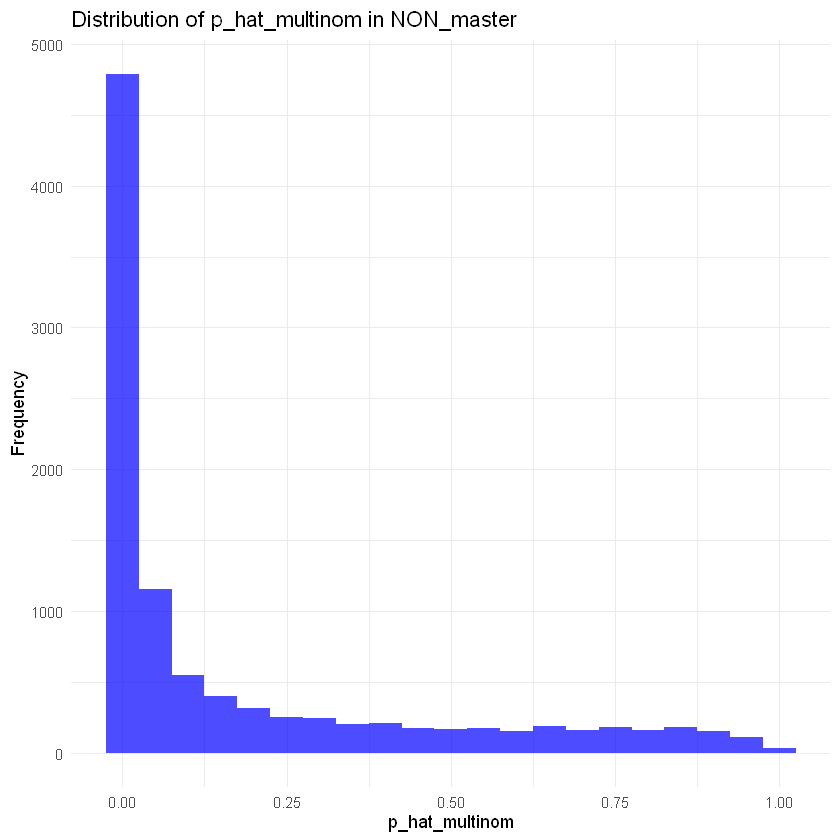

In [9]:
head(NON_master %>% 
    dplyr::select(dplyr::any_of(c(required_vars,"xfg_pred", "kick_distance","p_hat_multinom","weight_multinom_hajek"))) %>% 
    dplyr::select(kick_distance, xfg_pred, p_hat_multinom, weight_multinom_hajek, dplyr::everything()) %>% 
    dplyr::mutate(xfg_pred = round(xfg_pred, 3)))

# Show distribution of p_hat_multinom for NON_master
ggplot2::ggplot(NON_master, aes(x = p_hat_multinom)) +
    ggplot2::geom_histogram(binwidth = 0.05, fill = "blue", alpha = 0.7) +
    ggplot2::labs(title = "Distribution of p_hat_multinom in NON_master", x = "p_hat_multinom", y = "Frequency") +
    ggplot2::theme_minimal()

print(min(NON_master$p_hat_multinom, na.rm = TRUE))
print(max(NON_master$p_hat_multinom, na.rm = TRUE))
# Percent of NON_master observations with p_hat_multinom above 25%, 50%, 75%
thresholds <- c(0.05, 0.1, 0.25, 0.50, 0.75)
total_obs <- sum(!is.na(NON_master$p_hat_multinom))

res_df <- tibble::tibble(threshold = thresholds) %>%
    dplyr::rowwise() %>%
    dplyr::mutate(
        count = sum(NON_master$p_hat_multinom > threshold, na.rm = TRUE),
        pct = if (total_obs > 0) count / total_obs else NA_real_
    ) %>%
    dplyr::ungroup() %>%
    dplyr::mutate(
        threshold_label = scales::percent(threshold),
        pct_label = scales::percent(pct, accuracy = 0.1)
    ) %>%
    dplyr::select(threshold_label, count, pct_label)

print(glue::glue("Total non-attempt rows with non-missing p_hat_multinom: {total_obs}"))
print(res_df)

#Verify kick_made is 0 for all NON_master rows
if (any(NON_master$kick_made != 0)) {
    stop("Data integrity check failed: Some NON_master rows have kick_made != 0")
} else {
    cat("Data integrity check passed: All NON_master rows have kick_made == 0\n")
}

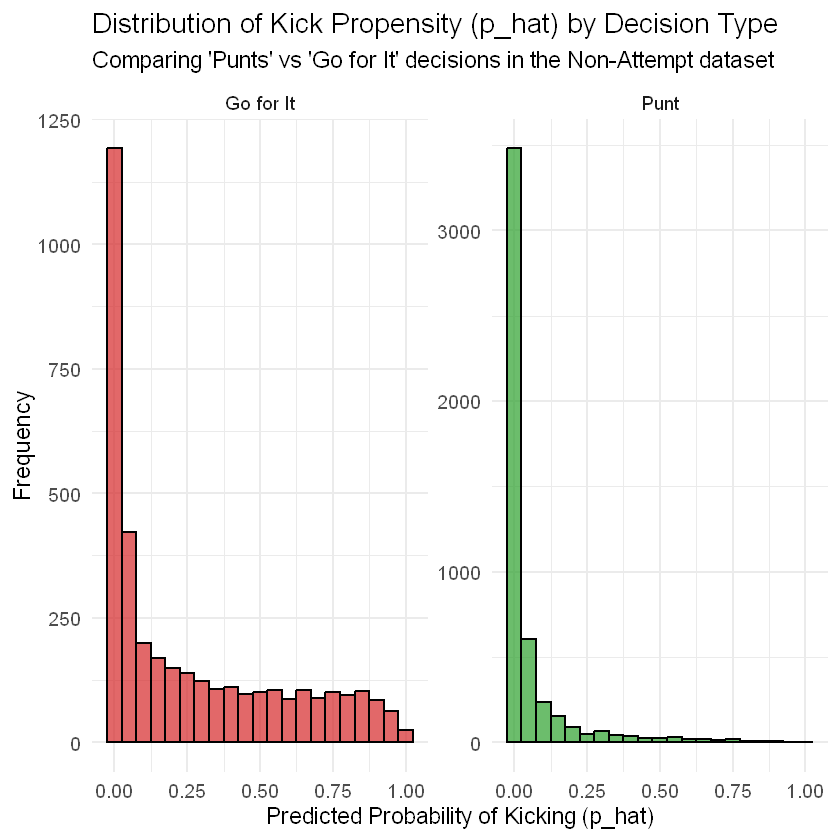

In [10]:
# Create a labeled version of NON_master for plotting
non_plot_data <- NON_master %>%
    dplyr::filter(kick_distance > 33) %>%   
  dplyr::mutate(
    play_class = dplyr::case_when(
      play_type_original == "punt" ~ "Punt",
      play_type_original %in% c("pass", "run") ~ "Go for It",
      TRUE ~ "Other"
    )
  ) %>%
  # Filter out any potential noise (though NON_master should only be these types)
  dplyr::filter(play_class %in% c("Punt", "Go for It"))

# Plot: Faceted Histogram
ggplot2::ggplot(non_plot_data, aes(x = p_hat_multinom, fill = play_class)) +
    ggplot2::geom_histogram(binwidth = 0.05, alpha = 0.7, color = "black") +
    ggplot2::facet_wrap(~play_class, scales = "free_y", ncol = 2) +
    ggplot2::scale_fill_manual(values = c("Go for It" = "#d62728", "Punt" = "#2ca02c")) +
    ggplot2::labs(
        title = "Distribution of Kick Propensity (p_hat) by Decision Type",
        subtitle = "Comparing 'Punts' vs 'Go for It' decisions in the Non-Attempt dataset",
        x = "Predicted Probability of Kicking (p_hat)",
        y = "Frequency"
    ) +
    ggplot2::theme_minimal(base_size = 14) +
    ggplot2::theme(legend.position = "none")


Data Reduction Analysis:
Total Non-Attempts: 9981
M3 Included Non-Attempts: 1789 (17.9%)


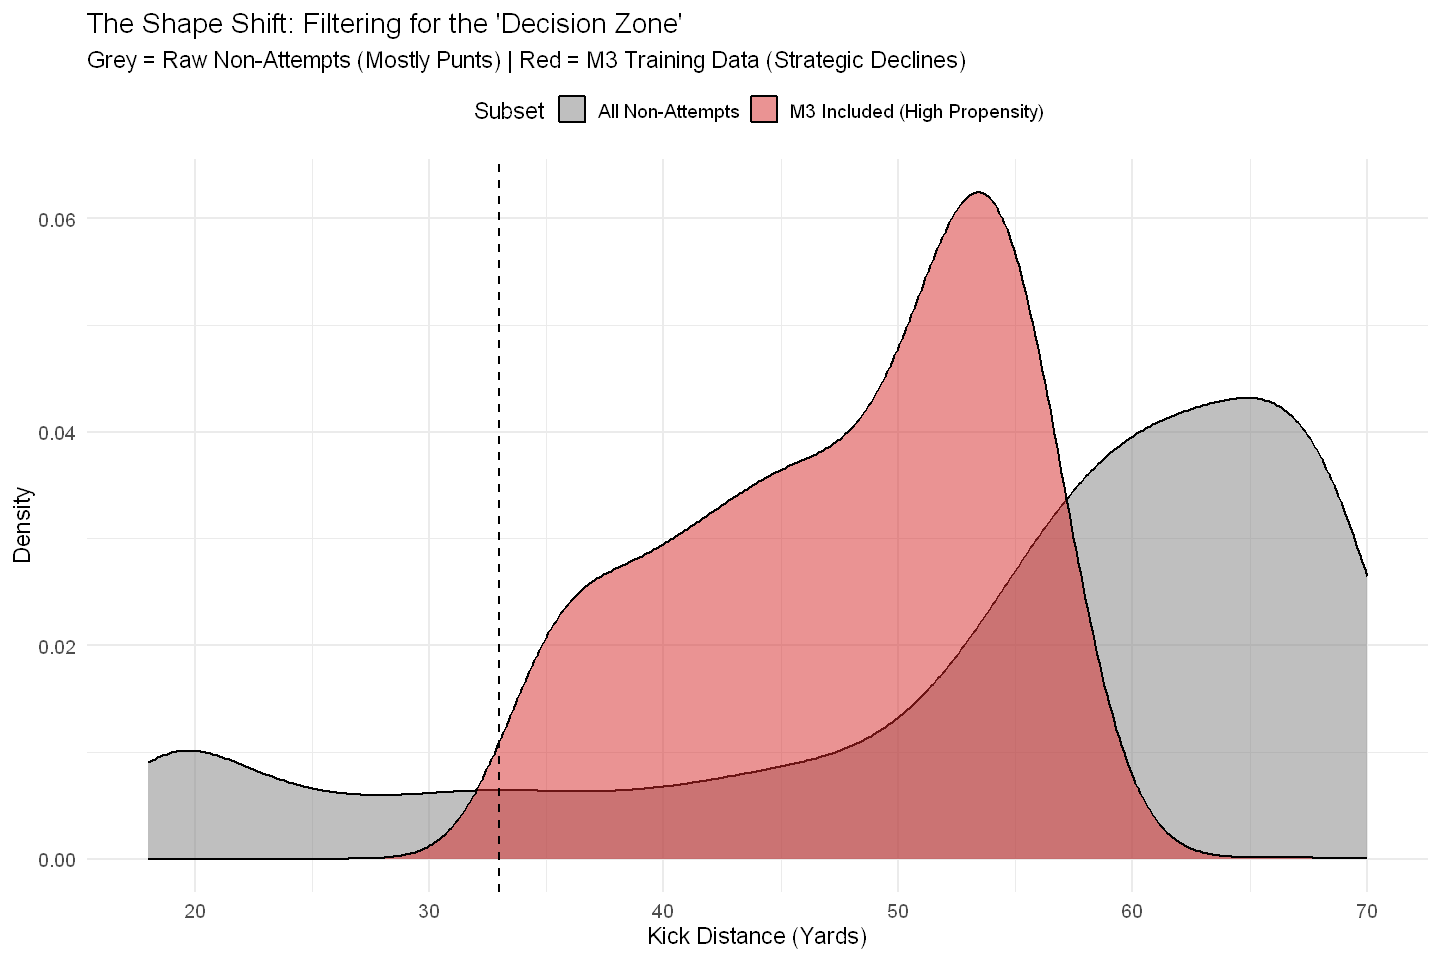


--- Distance Distribution Summary ---
# A tibble: 2 × 7
  Subset                            N Mean_Dist Median_Dist   P25   P75 SD_Dist
  <chr>                         <int>     <dbl>       <dbl> <dbl> <dbl>   <dbl>
1 All Non-Attempts               9981      54.2          59    48    65   14.8 
2 M3 Included (High Propensity)  1789      47.8          49    42    54    6.85


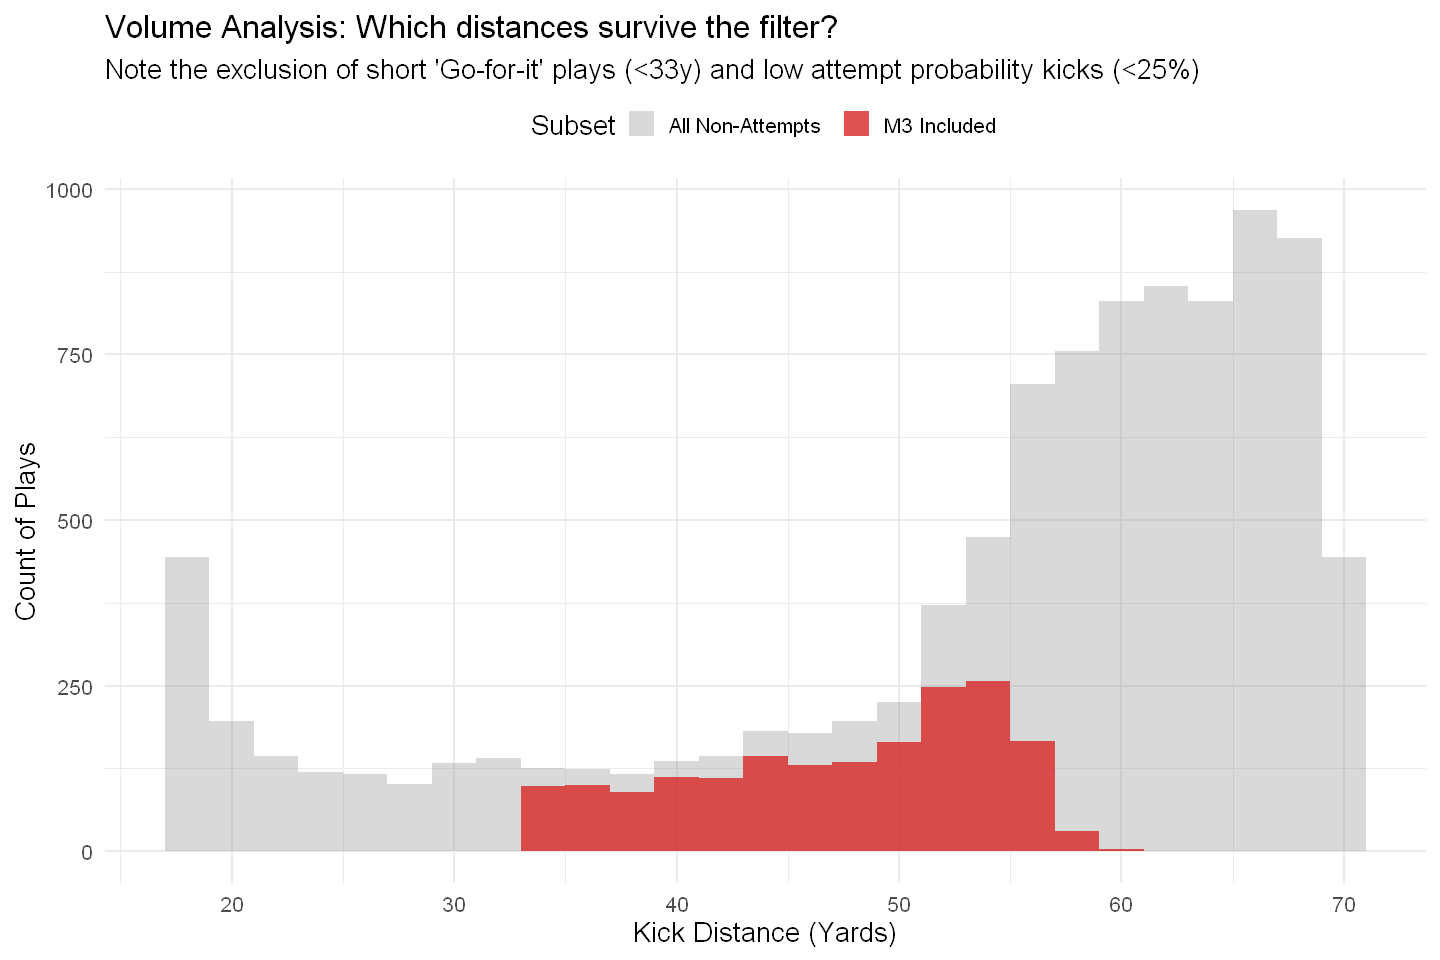

In [26]:
# ==============================================================================
# 1. Define the Subsets (Full vs. M3 Included)
# ==============================================================================

# A. The Full Non-Attempt Universe
# (Already loaded as NON_master)

# B. The "M3 Included" Subset
# Applying the Champion Model Rules: pi > 0.20 AND dist > 33
non_m3_subset <- NON_master %>%
  dplyr::filter(
    p_hat_attempt_clipped >= 0.25,
    kick_distance > 33
  )

cat(sprintf("\nData Reduction Analysis:\n"))
cat(sprintf("Total Non-Attempts: %d\n", nrow(NON_master)))
cat(sprintf("M3 Included Non-Attempts: %d (%.1f%%)\n", 
            nrow(non_m3_subset), (nrow(non_m3_subset)/nrow(NON_master))*100))

# ==============================================================================
# 2. Visual 1: The "Shape Shift" (Overlaid Density)
# ==============================================================================

# Combine for plotting
plot_dist_data <- dplyr::bind_rows(
  NON_master %>% dplyr::mutate(Subset = "All Non-Attempts"),
  non_m3_subset %>% dplyr::mutate(Subset = "M3 Included (High Propensity)")
)

p_dist_shape <- ggplot(plot_dist_data, aes(x = kick_distance, fill = Subset)) +
  # Use standard density to show the shape (area = 1)
  geom_density(alpha = 0.5, adjust = 1.5) + 
  scale_fill_manual(values = c("All Non-Attempts" = "grey50", "M3 Included (High Propensity)" = "#d62728")) +
  geom_vline(xintercept = 33, linetype = "dashed", color = "black") +
  labs(
    title = "The Shape Shift: Filtering for the 'Decision Zone'",
    subtitle = "Grey = Raw Non-Attempts (Mostly Punts) | Red = M3 Training Data (Strategic Declines)",
    x = "Kick Distance (Yards)",
    y = "Density"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "top")

print(p_dist_shape)

# ==============================================================================
# 3. Visual 2: Histogram Comparison (Counts)
# ==============================================================================
# This shows the raw volume drop-off

p_hist_comp <- ggplot() +
  # Background: All Data
  geom_histogram(data = NON_master, aes(x = kick_distance, fill = "All Non-Attempts"), 
                 binwidth = 2, alpha = 0.3) +
  # Foreground: Included Data
  geom_histogram(data = non_m3_subset, aes(x = kick_distance, fill = "M3 Included"), 
                 binwidth = 2, alpha = 0.8) +
  scale_fill_manual(name = "Subset", values = c("All Non-Attempts" = "grey50", "M3 Included" = "#d62728")) +
  labs(
    title = "Volume Analysis: Which distances survive the filter?",
    subtitle = "Note the exclusion of short 'Go-for-it' plays (<33y) and low attempt probability kicks (<25%)",
    x = "Kick Distance (Yards)",
    y = "Count of Plays"
  ) +
  theme_minimal(base_size = 16) +
  theme(legend.position = "top")

print(p_hist_comp)

# ==============================================================================
# 4. Summary Statistics
# ==============================================================================

dist_summary <- plot_dist_data %>%
  group_by(Subset) %>%
  summarise(
    N = n(),
    Mean_Dist = mean(kick_distance),
    Median_Dist = median(kick_distance),
    P25 = quantile(kick_distance, 0.25),
    P75 = quantile(kick_distance, 0.75),
    SD_Dist = sd(kick_distance)
  )

cat("\n--- Distance Distribution Summary ---\n")
print(dist_summary)

In [12]:
# Define augmentation variants for train-test experimentation
experiment_grid <- tibble::tribble(
  ~variant_id,          ~include_pat, ~w_pat, ~include_non, ~non_pi_cutoff, ~w_non_type, ~non_dist_filter, ~non_play_type_filter,
  # --- PAT-only variant ---
  "pat_w0.10",          TRUE,         0.10,   FALSE,        NA,             NA,           NA,                NA,
  "pat_w0.25",          TRUE,         0.25,   FALSE,        NA,             NA,           NA,                NA,
  "pat_w0.50",          TRUE,         0.50,   FALSE,        NA,             NA,           NA,                NA,
  "pat_w1.0",          TRUE,         1.00,   FALSE,        NA,             NA,           NA,                NA,
  
  # --- NON-only variants (fixed weight, pi_cutoff=0.1, with filters) ---
  "nonFix_pi10_dist<=50",  FALSE,        NA,    TRUE,         0.10,           "fixed",      "<=50",            NA,
  "nonFix_pi10_dist>33",   FALSE,        NA,    TRUE,         0.10,           "fixed",      ">33",             NA,
  "nonFix_pi10_dist30-60", FALSE,        NA,    TRUE,         0.10,           "fixed",      "30-60",           NA,
  "nonFix_pi10_no_punt",   FALSE,        NA,    TRUE,         0.10,           "fixed",      NA,                "no_punt",
  # --- NON-only variants (xfg_pred weight, pi_cutoff=0.10, with filters) ---
  "nonXFG_pi10_dist<=50",  FALSE,        NA,    TRUE,         0.10,           "xfg_pred",   "<=50",            NA,
  "nonXFG_pi10_dist>33",   FALSE,        NA,    TRUE,         0.10,           "xfg_pred",   ">33",             NA,
  "nonXFG_pi10_dist30-60", FALSE,        NA,    TRUE,         0.10,           "xfg_pred",   "30-60",           NA,
  "nonXFG_pi10_no_punt",   FALSE,        NA,    TRUE,         0.10,           "xfg_pred",   NA,                "no_punt"
)

# --- Display the grid to verify its structure ---
print(experiment_grid)
#print(ctrl)


# A tibble: 12 × 8
   variant_id            include_pat w_pat include_non non_pi_cutoff w_non_type
   <chr>                 <lgl>       <dbl> <lgl>               <dbl> <chr>     
 1 pat_w0.10             TRUE         0.1  FALSE                NA   NA        
 2 pat_w0.25             TRUE         0.25 FALSE                NA   NA        
 3 pat_w0.50             TRUE         0.5  FALSE                NA   NA        
 4 pat_w1.0              TRUE         1    FALSE                NA   NA        
 5 nonFix_pi10_dist<=50  FALSE       NA    TRUE                  0.1 fixed     
 6 nonFix_pi10_dist>33   FALSE       NA    TRUE                  0.1 fixed     
 7 nonFix_pi10_dist30-60 FALSE       NA    TRUE                  0.1 fixed     
 8 nonFix_pi10_no_punt   FALSE       NA    TRUE                  0.1 fixed     
 9 nonXFG_pi10_dist<=50  FALSE       NA    TRUE                  0.1 xfg_pred  
10 nonXFG_pi10_dist>33   FALSE       NA    TRUE                  0.1 xfg_pred  
11 nonXFG_pi10_dist30

In [13]:
# --- Main Experiment Loop (Finalized) ---

# --- Test Mode Configuration ---
test_mode <- FALSE

# --- Prerequisites ---
stopifnot(exists("train_df"), exists("test_df"), exists("PAT_master"), 
          exists("NON_master"), exists("m1_formula"), exists("experiment_grid"), 
          exists("augmented_reports_dir"), exists("build_distance_bs"))

# Container for all results
all_results <- list() 

# Initialize lists for raw predictions
all_train_predictions <- list()
all_test_predictions <- list()

# Define train_game_ids
train_game_ids <- unique(train_df$game_id)

# Suppress warnings
options(warn = -1) 

# --- Create Grid ---
grid_to_run <- if (isTRUE(test_mode)) {
  if (nrow(experiment_grid) > 1) {
    indices_to_run <- unique(c(1, nrow(experiment_grid)))
    cat(sprintf("--- TEST MODE: Running variants %s ---\n", 
                paste(experiment_grid$variant_id[indices_to_run], collapse = " and ")))
    experiment_grid[indices_to_run, ]
  } else {
    cat("--- TEST MODE: Running the single available variant ---\n")
    experiment_grid
  }
} else {
  cat("--- FULL MODE: Running all variants ---\n")
  experiment_grid
}

# --- Iteration ---
for (i in 1:nrow(grid_to_run)) {
  cfg <- grid_to_run[i, ]
  vid <- cfg$variant_id
  
  cat(sprintf("\n--- Running Variant: %s ---\n", vid))
  flush.console()
  
  result <- tryCatch({
    start_time <- Sys.time()
    
    # 1. Build Augmented Training Data
    cat("Step 1: Building augmented training data...\n")
    flush.console()
    
    # A. FG data (Base)
    train_df_w <- train_df %>% dplyr::mutate(obs_weight = 1.0, src = "FG")

    # B. PAT data
    train_pats <- if (!is.na(cfg$w_pat)) {
      PAT_master %>%
        dplyr::filter(game_id %in% train_game_ids) %>%
        dplyr::mutate(obs_weight = cfg$w_pat, src = "PAT")
    } else {
      tibble::tibble()
    }

    # C. NON data
    train_non <- if (isTRUE(cfg$include_non)) {
      non_filtered <- NON_master %>%
        dplyr::filter(game_id %in% train_game_ids, p_hat_multinom >= cfg$non_pi_cutoff)
      
      # Distance Filters
      if ("non_dist_filter" %in% names(cfg) && !is.na(cfg$non_dist_filter)) {
        if (cfg$non_dist_filter == "<=50") {
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance <= 50)
        } else if (cfg$non_dist_filter == ">33") {
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 33)
        } else if (cfg$non_dist_filter == "30-60") {
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance >= 30, kick_distance <= 60)
        }
      }
      
      # Play Type Filters
      if ("non_play_type_filter" %in% names(cfg) && !is.na(cfg$non_play_type_filter)) {
        if (cfg$non_play_type_filter == "no_punt") {
          non_filtered <- non_filtered %>% dplyr::filter(play_type_original != "punt")
        }
      }
      
      non_filtered %>%
        dplyr::mutate(
          src = "NON",
          obs_weight = dplyr::case_when(
            cfg$w_non_type == "fixed"    ~ 0.1, 
            cfg$w_non_type == "xfg_pred" ~ xfg_pred,
            TRUE ~ 0.0
          )
        )
    } else {
      tibble::tibble() 
    }
    
    # 2. Combine & Regenerate Splines
    train_aug <- dplyr::bind_rows(train_df_w, train_pats, train_non) %>%
      dplyr::select(-dplyr::starts_with("dist_bs_")) %>% 
      dplyr::filter(!is.na(obs_weight), is.finite(obs_weight), obs_weight > 1e-6)

    # Re-apply splines using global knots
    aug_splines <- build_distance_bs(train_aug$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
    train_aug <- dplyr::bind_cols(train_aug, aug_splines)
    
    if (nrow(train_aug) == 0) stop("Generated training data is empty.")
    
    cat(sprintf(" -> Generated dataset: %d rows (FG=%d, PAT=%d, NON=%d). Total weight=%.1f\n",
                nrow(train_aug), nrow(train_df_w), nrow(train_pats), nrow(train_non),
                sum(as.numeric(train_aug$obs_weight), na.rm=TRUE)))
    flush.console()
    
    # 3. Pool sparse kickers
    cat("Step 2: Pooling sparse kickers...\n")
    pooled_data <- pool_sparse_levels(train_aug, test_df, id_col = "kicker_player_id", min_n = 5L)
    train_pooled <- pooled_data$train
    test_pooled  <- pooled_data$test
    flush.console()
    
    # CRITICAL FIX: Add dummy weight column to test set
    test_pooled$obs_weight <- 1.0 
    
    # 4. Fit the augmented model
    cat("Step 3: Fitting glmmTMB model...\n")
    flush.console()
    fit_aug <- glmmTMB::glmmTMB(
        m1_formula,
        data = train_pooled,
        family = binomial(link = "logit"), 
        weights = obs_weight,
        control = ctrl
    )
    flush.console()

    # 5. Convergence check
    cat("Step 4: Checking convergence...\n")
    if (fit_aug$fit$convergence != 0) stop(sprintf("Convergence code: %d", fit_aug$fit$convergence))
    cat(" -> Converged.\n")
    flush.console()

    # 6. Evaluate
    cat("Step 5: Evaluating...\n")
    flush.console()
    
    p_aug_train <- predict_safe(fit_aug, train_pooled)
    p_aug_test  <- predict_safe(fit_aug, test_pooled)
    
    # Calculate metrics (now includes acc/rec/prec/f1)
    aug_metrics <- dplyr::bind_rows(
      calc_metrics(train_pooled$kick_made, p_aug_train, set_name = "train"),
      calc_metrics(test_pooled$kick_made, p_aug_test,  set_name = "test")
    ) %>% dplyr::mutate(variant = vid, .before = 1)
    
    # Store Predictions
    all_test_predictions[[vid]] <- tibble::tibble(
      variant = vid, kick_made = test_pooled$kick_made,
      kick_distance = test_pooled$kick_distance, p_hat = p_aug_test
    )

    all_train_predictions[[vid]] <- tibble::tibble(
      variant = vid, kick_made = train_pooled$kick_made,
      kick_distance = train_pooled$kick_distance, p_hat = p_aug_train,
      src = train_pooled$src
    )
    
    end_time <- Sys.time()
    cat(sprintf("Variant %s completed in %.2f secs.\n", vid, difftime(end_time, start_time, units = "secs")))
    flush.console()
    
    aug_metrics

  }, error = function(e) {
    cat(sprintf("\n*** ERROR in variant: %s ***\nMsg: %s\n\n", vid, conditionMessage(e)))
    flush.console()
    # Return empty metrics on fail
    dplyr::bind_rows(
        tibble::tibble(set = "train", brier=NA, logloss=NA, auc=NA, calib_error=NA, accuracy=NA, f1_score=NA),
        tibble::tibble(set = "test",  brier=NA, logloss=NA, auc=NA, calib_error=NA, accuracy=NA, f1_score=NA)
    ) %>% dplyr::mutate(variant = vid, .before = 1)
  })
  
  all_results[[vid]] <- result
}

options(warn = 0) # Restore warnings

# --- Compile and Save Results ---

# 1. Predictions
final_test_predictions <- dplyr::bind_rows(all_test_predictions)
predictions_path <- file.path(augmented_reports_dir, 'fg_model_experiment_test_predictions_v1.csv')
readr::write_csv(final_test_predictions, predictions_path)
cat(sprintf("\nTest preds saved: %s\n", predictions_path))

final_train_predictions <- dplyr::bind_rows(all_train_predictions)
train_predictions_path <- file.path(augmented_reports_dir, 'fg_model_experiment_train_predictions_v1.csv')
readr::write_csv(final_train_predictions, train_predictions_path)
cat(sprintf("Train preds saved: %s\n", train_predictions_path))

# 2. Results (Combine with Baseline)
experimental_results <- dplyr::bind_rows(all_results)

# Load Baseline if it exists
baseline_path <- file.path(augmented_reports_dir, 'baseline_fg_only_metrics.csv')
if (file.exists(baseline_path)) {
  baseline_results <- readr::read_csv(baseline_path, show_col_types = FALSE)
  final_results <- dplyr::bind_rows(baseline_results, experimental_results)
} else {
  final_results <- experimental_results
  warning("Baseline metrics file not found. Final results contain only experimental variants.")
}

# Save Final
results_path <- file.path(augmented_reports_dir, 'fg_model_experiment_results_v1.csv')
readr::write_csv(final_results, results_path)
cat(sprintf("Results saved: %s\n", results_path))

cat("\n--- Final Experiment Results (Top 10 by Test AUC) ---\n")
final_results %>% 
  dplyr::filter(set == "test") %>% 
  dplyr::arrange(desc(auc)) %>% 
  head(10) %>% 
  print()

--- FULL MODE: Running all variants ---

--- Running Variant: pat_w0.10 ---
Step 1: Building augmented training data...
 -> Generated dataset: 15859 rows (FG=7238, PAT=8621, NON=0). Total weight=8100.1
Step 2: Pooling sparse kickers...
Step 3: Fitting glmmTMB model...
Step 4: Checking convergence...
 -> Converged.
Step 5: Evaluating...
Variant pat_w0.10 completed in 14.14 secs.

--- Running Variant: pat_w0.25 ---
Step 1: Building augmented training data...
 -> Generated dataset: 15859 rows (FG=7238, PAT=8621, NON=0). Total weight=9393.2
Step 2: Pooling sparse kickers...
Step 3: Fitting glmmTMB model...
Step 4: Checking convergence...
 -> Converged.
Step 5: Evaluating...
Variant pat_w0.25 completed in 14.76 secs.

--- Running Variant: pat_w0.50 ---
Step 1: Building augmented training data...
 -> Generated dataset: 15859 rows (FG=7238, PAT=8621, NON=0). Total weight=11548.5
Step 2: Pooling sparse kickers...
Step 3: Fitting glmmTMB model...
Step 4: Checking convergence...
 -> Converged.
S

In [14]:
# --- Experiment Grid V2: Refinement & Combinations ---

experiment_grid_2 <- tibble::tribble(
  ~variant_id,              ~include_pat, ~w_pat, ~include_non, ~non_pi_cutoff, ~w_non_type, ~w_non_fixed, ~non_xfg_threshold, ~non_dist_filter, ~non_play_type_filter,
  
  # 1. Baseline (Reference)
  "baseline_v2",            FALSE,        NA,     FALSE,        NA,             NA,          NA,           NA,                 NA,               NA,

  # 2. PAT Optimization (Narrowing the "Anchor")
  # w0.25 had best calibration, w0.10 had best AUC. Testing the middle ground.
  "pat_w0.15",              TRUE,         0.15,   FALSE,        NA,             NA,          NA,           NA,                 NA,               NA,

  # 3. NON Optimization (Stricter Filters)
  # V1 Winner was dist>33, pi10. V2 tightens to dist>35 and pi20 (The "Decision Zone")
  "non_fix0.1_pi20_d35",    FALSE,        NA,     TRUE,         0.20,           "fixed",     0.10,         0.95,               ">35",            NA,
  
  # 4. Calibration Check (Lower NON Weight)
  # NONs hurt calibration in V1. Testing half-weight (0.05) to see if it preserves AUC while fixing calibration.
  "non_fix0.05_pi20_d35",   FALSE,        NA,     TRUE,         0.20,           "fixed",     0.05,         0.95,               ">35",            NA,

  # --- COMBINATIONS (The Hypothesis: Anchors + Decision Zone) ---
  
  # 5. The "Balanced" Combo
  # PATs stabilize the short end, NONs inform the long end.
  "combo_pat0.15_non0.1",   TRUE,         0.15,   TRUE,         0.20,           "fixed",     0.10,         0.95,               ">35",            NA,

  # 6. The "Conservative" Combo
  # Lighter weights on both to preserve the signal of actual FGs.
  "combo_pat0.10_non0.05",  TRUE,         0.10,   TRUE,         0.20,           "fixed",     0.05,         0.95,               ">35",            NA,

  # 7. The "High Propensity" Test
  # Only including NONs that were extremely likely to be kicks (>30%), treating them as misses.
  "combo_pat0.15_pi30",     TRUE,         0.15,   TRUE,         0.30,           "fixed",     0.10,         0.95,               ">35",            NA
)


# Print summary of V2
cat(sprintf("Loaded Experiment Grid V2 with %d variants.\n", nrow(experiment_grid_2)))
print(experiment_grid_2 %>% dplyr::select(variant_id, include_pat, include_non, w_non_fixed))

Loaded Experiment Grid V2 with 7 variants.
# A tibble: 7 × 4
  variant_id            include_pat include_non w_non_fixed
  <chr>                 <lgl>       <lgl>             <dbl>
1 baseline_v2           FALSE       FALSE             NA   
2 pat_w0.15             TRUE        FALSE             NA   
3 non_fix0.1_pi20_d35   FALSE       TRUE               0.1 
4 non_fix0.05_pi20_d35  FALSE       TRUE               0.05
5 combo_pat0.15_non0.1  TRUE        TRUE               0.1 
6 combo_pat0.10_non0.05 TRUE        TRUE               0.05
7 combo_pat0.15_pi30    TRUE        TRUE               0.1 


In [15]:
# --- Main Experiment Loop (Finalized) ---

# --- Test Mode Configuration ---
test_mode <- FALSE

# --- Prerequisites ---
stopifnot(exists("train_df"), exists("test_df"), exists("PAT_master"), 
          exists("NON_master"), exists("m1_formula"), exists("experiment_grid"), 
          exists("augmented_reports_dir"), exists("build_distance_bs"))

# Container for all results
all_results <- list() 

# Initialize lists for raw predictions
all_train_predictions <- list()
all_test_predictions <- list()

# Define train_game_ids
train_game_ids <- unique(train_df$game_id)

# Suppress warnings
options(warn = -1) 

# --- Create Grid ---
grid_to_run <- if (isTRUE(test_mode)) {
  if (nrow(experiment_grid_2) > 1) {
    indices_to_run <- unique(c(1, nrow(experiment_grid_2)))
    cat(sprintf("--- TEST MODE: Running variants %s ---\n", 
                paste(experiment_grid_2$variant_id[indices_to_run], collapse = " and ")))
    experiment_grid_2[indices_to_run, ]
  } else {
    cat("--- TEST MODE: Running the single available variant ---\n")
    experiment_grid_2
  }
} else {
  cat("--- FULL MODE: Running all variants ---\n")
  experiment_grid_2
}

# --- Iteration ---
for (i in 1:nrow(grid_to_run)) {
  cfg <- grid_to_run[i, ]
  vid <- cfg$variant_id
  
  cat(sprintf("\n--- Running Variant: %s ---\n", vid))
  flush.console()
  
  result <- tryCatch({
    start_time <- Sys.time()
    
    # 1. Build Augmented Training Data
    cat("Step 1: Building augmented training data...\n")
    flush.console()
    
    # A. FG data (Base)
    train_df_w <- train_df %>% dplyr::mutate(obs_weight = 1.0, src = "FG")

    # B. PAT data
    train_pats <- if (!is.na(cfg$w_pat)) {
      PAT_master %>%
        dplyr::filter(game_id %in% train_game_ids) %>%
        dplyr::mutate(obs_weight = cfg$w_pat, src = "PAT")
    } else {
      tibble::tibble()
    }

    # C. NON data
    train_non <- if (isTRUE(cfg$include_non)) {
      non_filtered <- NON_master %>%
        dplyr::filter(game_id %in% train_game_ids, p_hat_multinom >= cfg$non_pi_cutoff)
      
      # Distance Filters
      if ("non_dist_filter" %in% names(cfg) && !is.na(cfg$non_dist_filter)) {
        if (cfg$non_dist_filter == "<=50") {
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance <= 50)
        } else if (cfg$non_dist_filter == ">33") {
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 33)
        } else if (cfg$non_dist_filter == "30-60") {
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance >= 30, kick_distance <= 60)
        }
      }
      
      # Play Type Filters
      if ("non_play_type_filter" %in% names(cfg) && !is.na(cfg$non_play_type_filter)) {
        if (cfg$non_play_type_filter == "no_punt") {
          non_filtered <- non_filtered %>% dplyr::filter(play_type_original != "punt")
        }
      }
      
      non_filtered %>%
        dplyr::mutate(
          src = "NON",
          obs_weight = dplyr::case_when(
            cfg$w_non_type == "fixed"    ~ 0.1, 
            cfg$w_non_type == "xfg_pred" ~ xfg_pred,
            TRUE ~ 0.0
          )
        )
    } else {
      tibble::tibble() 
    }
    
    # 2. Combine & Regenerate Splines
    train_aug <- dplyr::bind_rows(train_df_w, train_pats, train_non) %>%
      dplyr::select(-dplyr::starts_with("dist_bs_")) %>% 
      dplyr::filter(!is.na(obs_weight), is.finite(obs_weight), obs_weight > 1e-6)

    # Re-apply splines using global knots
    aug_splines <- build_distance_bs(train_aug$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
    train_aug <- dplyr::bind_cols(train_aug, aug_splines)
    
    if (nrow(train_aug) == 0) stop("Generated training data is empty.")
    
    cat(sprintf(" -> Generated dataset: %d rows (FG=%d, PAT=%d, NON=%d). Total weight=%.1f\n",
                nrow(train_aug), nrow(train_df_w), nrow(train_pats), nrow(train_non),
                sum(as.numeric(train_aug$obs_weight), na.rm=TRUE)))
    flush.console()
    
    # 3. Pool sparse kickers
    cat("Step 2: Pooling sparse kickers...\n")
    pooled_data <- pool_sparse_levels(train_aug, test_df, id_col = "kicker_player_id", min_n = 5L)
    train_pooled <- pooled_data$train
    test_pooled  <- pooled_data$test
    flush.console()
    
    # CRITICAL FIX: Add dummy weight column to test set
    test_pooled$obs_weight <- 1.0 
    
    # 4. Fit the augmented model
    cat("Step 3: Fitting glmmTMB model...\n")
    flush.console()
    fit_aug <- glmmTMB::glmmTMB(
        m1_formula,
        data = train_pooled,
        family = binomial(link = "logit"), 
        weights = obs_weight,
        control = ctrl
    )
    flush.console()

    # 5. Convergence check
    cat("Step 4: Checking convergence...\n")
    if (fit_aug$fit$convergence != 0) stop(sprintf("Convergence code: %d", fit_aug$fit$convergence))
    cat(" -> Converged.\n")
    flush.console()

    # 6. Evaluate
    cat("Step 5: Evaluating...\n")
    flush.console()
    
    p_aug_train <- predict_safe(fit_aug, train_pooled)
    p_aug_test  <- predict_safe(fit_aug, test_pooled)
    
    # Calculate metrics (now includes acc/rec/prec/f1)
    aug_metrics <- dplyr::bind_rows(
      calc_metrics(train_pooled$kick_made, p_aug_train, set_name = "train"),
      calc_metrics(test_pooled$kick_made, p_aug_test,  set_name = "test")
    ) %>% dplyr::mutate(variant = vid, .before = 1)
    
    # Store Predictions
    all_test_predictions[[vid]] <- tibble::tibble(
      variant = vid, kick_made = test_pooled$kick_made,
      kick_distance = test_pooled$kick_distance, p_hat = p_aug_test
    )

    all_train_predictions[[vid]] <- tibble::tibble(
      variant = vid, kick_made = train_pooled$kick_made,
      kick_distance = train_pooled$kick_distance, p_hat = p_aug_train,
      src = train_pooled$src
    )
    
    end_time <- Sys.time()
    cat(sprintf("Variant %s completed in %.2f secs.\n", vid, difftime(end_time, start_time, units = "secs")))
    flush.console()
    
    aug_metrics

  }, error = function(e) {
    cat(sprintf("\n*** ERROR in variant: %s ***\nMsg: %s\n\n", vid, conditionMessage(e)))
    flush.console()
    # Return empty metrics on fail
    dplyr::bind_rows(
        tibble::tibble(set = "train", brier=NA, logloss=NA, auc=NA, calib_error=NA, accuracy=NA, f1_score=NA),
        tibble::tibble(set = "test",  brier=NA, logloss=NA, auc=NA, calib_error=NA, accuracy=NA, f1_score=NA)
    ) %>% dplyr::mutate(variant = vid, .before = 1)
  })
  
  all_results[[vid]] <- result
}

options(warn = 0) # Restore warnings

# --- Compile and Save Results ---

# 1. Predictions
final_test_predictions <- dplyr::bind_rows(all_test_predictions)
predictions_path <- file.path(augmented_reports_dir, 'fg_model_experiment_test_predictions_v2.csv')
readr::write_csv(final_test_predictions, predictions_path)
cat(sprintf("\nTest preds saved: %s\n", predictions_path))

final_train_predictions <- dplyr::bind_rows(all_train_predictions)
train_predictions_path <- file.path(augmented_reports_dir, 'fg_model_experiment_train_predictions_v2.csv')
readr::write_csv(final_train_predictions, train_predictions_path)
cat(sprintf("Train preds saved: %s\n", train_predictions_path))

# 2. Results (Combine with Baseline)
experimental_results <- dplyr::bind_rows(all_results)

# Load Baseline if it exists
baseline_path <- file.path(augmented_reports_dir, 'baseline_fg_only_metrics.csv')
if (file.exists(baseline_path)) {
  baseline_results <- readr::read_csv(baseline_path, show_col_types = FALSE)
  final_results <- dplyr::bind_rows(baseline_results, experimental_results)
} else {
  final_results <- experimental_results
  warning("Baseline metrics file not found. Final results contain only experimental variants.")
}

# Save Final
results_path <- file.path(augmented_reports_dir, 'fg_model_experiment_results_v2.csv')
readr::write_csv(final_results, results_path)
cat(sprintf("Results saved: %s\n", results_path))

cat("\n--- Final Experiment Results (Top 10 by Test AUC) ---\n")
final_results %>% 
  dplyr::filter(set == "test") %>% 
  dplyr::arrange(desc(auc)) %>% 
  head(10) %>% 
  print()

--- FULL MODE: Running all variants ---

--- Running Variant: baseline_v2 ---
Step 1: Building augmented training data...
 -> Generated dataset: 7238 rows (FG=7238, PAT=0, NON=0). Total weight=7238.0
Step 2: Pooling sparse kickers...
Step 3: Fitting glmmTMB model...
Step 4: Checking convergence...
 -> Converged.
Step 5: Evaluating...
Variant baseline_v2 completed in 7.59 secs.

--- Running Variant: pat_w0.15 ---
Step 1: Building augmented training data...
 -> Generated dataset: 15859 rows (FG=7238, PAT=8621, NON=0). Total weight=8531.1
Step 2: Pooling sparse kickers...
Step 3: Fitting glmmTMB model...
Step 4: Checking convergence...
 -> Converged.
Step 5: Evaluating...
Variant pat_w0.15 completed in 13.53 secs.

--- Running Variant: non_fix0.1_pi20_d35 ---
Step 1: Building augmented training data...
 -> Generated dataset: 9285 rows (FG=7238, PAT=0, NON=2047). Total weight=7442.7
Step 2: Pooling sparse kickers...
Step 3: Fitting glmmTMB model...
Step 4: Checking convergence...
 -> Conve

In [16]:
# --- Full In-Sample Inference Loop (Sanity Check) ---

# --- Prerequisites ---
stopifnot(exists("FG_master"), exists("PAT_master"), exists("NON_master"), 
          exists("experiment_grid_2"), exists("m1_formula"), 
          exists("calc_metrics"), exists("pool_sparse_levels"))


# Suppress warnings
options(warn = -1)

# Container for results
insample_results <- list()

# --- 1. Establish the "True" Baseline (FG Only, In-Sample) ---
cat("--- Step 0: Establishing In-Sample Baseline (FG Only) ---\n")

# Pool sparse levels on FG_master itself
# We create a dummy 'test' just to satisfy the function signature
pool_base <- pool_sparse_levels(FG_master, FG_master[1:5,], id_col = "kicker_player_id", min_n = 5L)
fg_pooled <- pool_base$train

# Fit Baseline
fit_base_insample <- glmmTMB::glmmTMB(m1_formula, data = fg_pooled, family = binomial(link = "logit"), control = ctrl)

# Predict on ITSELF
p_base_insample <- predict_safe(fit_base_insample, fg_pooled)

# Calculate Baseline Metrics
baseline_metrics <- calc_metrics(fg_pooled$kick_made, p_base_insample, set_name = "in_sample") %>%
  dplyr::mutate(variant = "baseline_fg_insample", .before = 1)

# Add to results
insample_results[["baseline"]] <- baseline_metrics
print(baseline_metrics)

# --- 2. The Augmented Loop ---
cat("\n--- Starting Augmented Inference Loop ---\n")

for (i in 1:nrow(experiment_grid_2)) {
  cfg <- experiment_grid_2[i, ]
  vid <- cfg$variant_id
  
  # Skip if it's the baseline row (we just did it)
  if (vid == "baseline_v2") next
  
  cat(sprintf("\n--- Processing Variant: %s ---\n", vid))
  flush.console()
  
  tryCatch({
    # A. Build Augmented Training Data (FG + PAT + NON)
    # Note: We use FG_master as the base, weighted 1.0
    train_df_w <- FG_master %>% dplyr::mutate(obs_weight = 1.0, src = "FG")
    
    # PATs
    train_pats <- if (!is.na(cfg$w_pat)) {
      PAT_master %>% dplyr::mutate(obs_weight = cfg$w_pat, src = "PAT")
    } else { tibble::tibble() }
    
    # NONs
    train_non <- if (isTRUE(cfg$include_non)) {
      non_filtered <- NON_master %>% 
        dplyr::filter(p_hat_multinom >= cfg$non_pi_cutoff)
      
      # Distance Filter
      if ("non_dist_filter" %in% names(cfg) && !is.na(cfg$non_dist_filter)) {
         if (cfg$non_dist_filter == ">35") non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 35)
         else if (cfg$non_dist_filter == ">33") non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 33)
      }
      
      non_filtered %>%
        dplyr::mutate(
          src = "NON",
          obs_weight = dplyr::case_when(
            cfg$w_non_type == "fixed" ~ cfg$w_non_fixed,
            TRUE ~ 0.0
          )
        )
    } else { tibble::tibble() }
    
    # B. Combine & Regenerate Splines
    train_aug <- dplyr::bind_rows(train_df_w, train_pats, train_non) %>%
      dplyr::select(-dplyr::starts_with("dist_bs_")) %>%
      dplyr::filter(!is.na(obs_weight), is.finite(obs_weight), obs_weight > 1e-6)
      
    aug_splines <- build_distance_bs(train_aug$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
    train_aug <- dplyr::bind_cols(train_aug, aug_splines)
    
    cat(sprintf(" -> Training Data: %d rows (FG=%d, PAT=%d, NON=%d)\n", 
                nrow(train_aug), nrow(train_df_w), nrow(train_pats), nrow(train_non)))
    
    # C. Pool Sparse Levels
    # CRITICAL: We Treat 'Augmented' as Train, and 'FG_master' as Test
    # This ensures consistent factor levels for the prediction step
    fg_eval <- FG_master # The target evaluation set
    # Ensure fg_eval has splines too (it should, but safety first)
    if(!"dist_bs_1" %in% names(fg_eval)) {
        fg_splines <- build_distance_bs(fg_eval$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
        fg_eval <- dplyr::bind_cols(fg_eval, fg_splines)
    }
    
    # Pool
    pooled_data <- pool_sparse_levels(train_aug, fg_eval, id_col = "kicker_player_id", min_n = 5L)
    train_pooled <- pooled_data$train
    fg_eval_pooled <- pooled_data$test
    
    # Add dummy weight to eval set for glmmTMB signature
    fg_eval_pooled$obs_weight <- 1.0
    
    # D. Fit Model
    fit_aug <- glmmTMB::glmmTMB(
        m1_formula,
        data = train_pooled,
        family = binomial(link = "logit"),
        weights = obs_weight,
        control = ctrl
    )
    
    # E. Predict on FG_master (The Evaluation Set)
    p_insample <- predict_safe(fit_aug, fg_eval_pooled)
    
    # F. Metrics
    metrics <- calc_metrics(fg_eval_pooled$kick_made, p_insample, set_name = "in_sample") %>%
      dplyr::mutate(variant = vid, .before = 1)
      
    # G. Calculate Delta vs Baseline
    metrics <- metrics %>%
      dplyr::mutate(
        auc_delta = auc - baseline_metrics$auc,
        brier_delta = brier - baseline_metrics$brier,
        calib_delta = calib_error - baseline_metrics$calib_error
      )
      
    insample_results[[vid]] <- metrics
    print(metrics %>% dplyr::select(variant, auc, brier_delta, calib_delta))
    
  }, error = function(e) {
    cat(sprintf("Error in %s: %s\n", vid, conditionMessage(e)))
  })
}

options(warn = 0)

# --- 3. Compile & Display ---
final_insample_comparison <- dplyr::bind_rows(insample_results) %>%
    dplyr::arrange(desc(auc))

cat("\n--- Final In-Sample Inference Check (Evaluation on FG Master) ---\n")
print(final_insample_comparison %>% 
      dplyr::select(variant, auc, brier, logloss, calib_error, brier_delta, calib_delta))

# Save
readr::write_csv(final_insample_comparison, file.path(augmented_reports_dir, 'final_insample_inference_check.csv'))

--- Step 0: Establishing In-Sample Baseline (FG Only) ---
# A tibble: 1 × 10
  variant        set   brier logloss   auc calib_error accuracy precision recall
  <chr>          <chr> <dbl>   <dbl> <dbl>       <dbl>    <dbl>     <dbl>  <dbl>
1 baseline_fg_i… in_s… 0.101   0.325 0.808      0.0155    0.864     0.866  0.996
# ℹ 1 more variable: f1_score <dbl>

--- Starting Augmented Inference Loop ---

--- Processing Variant: pat_w0.15 ---
 -> Training Data: 23071 rows (FG=10432, PAT=12639, NON=0)
# A tibble: 1 × 4
  variant     auc brier_delta calib_delta
  <chr>     <dbl>       <dbl>       <dbl>
1 pat_w0.15 0.805    0.000455    0.000249

--- Processing Variant: non_fix0.1_pi20_d35 ---
 -> Training Data: 12342 rows (FG=10432, PAT=0, NON=1910)
# A tibble: 1 × 4
  variant               auc brier_delta calib_delta
  <chr>               <dbl>       <dbl>       <dbl>
1 non_fix0.1_pi20_d35 0.802    0.000760   -0.000668

--- Processing Variant: non_fix0.05_pi20_d35 ---
 -> Training Data: 12342 row

In [17]:
# --- Final Granular Comparison: Baseline vs. Champion (Robust) ---

# 1. Configuration (Explicitly Defined to avoid lookup errors)
champion_id <- "combo_patw0.10_nonw0.10_d33"

# Define parameters manually to ensure robustness
champ_params <- list(
  w_pat = 0.10,
  include_non = TRUE,
  non_pi_cutoff = 0.20,
  w_non_fixed = 0.1,
  non_dist_filter = ">33"
)

cat(sprintf("--- Detailed Comparison: Baseline vs %s ---\n", champion_id))

# 2. Fit the Champion Model (In-Sample)
# Re-building the training data for the champion one last time
cat("Building Champion Data...\n")

# A. Base FG
train_df_w <- FG_master %>% dplyr::mutate(obs_weight = 1.0, src = "FG")

# B. PATs (Using explicit param)
train_pats <- PAT_master %>% 
  dplyr::mutate(obs_weight = champ_params$w_pat, src = "PAT")

# C. NONs (Using explicit params)
train_non <- NON_master %>% 
  dplyr::filter(p_hat_multinom >= champ_params$non_pi_cutoff) %>%
  dplyr::filter(kick_distance > 35) %>% 
  dplyr::mutate(
      src = "NON", 
      obs_weight = champ_params$w_non_fixed
  )

# Combine
train_champ <- dplyr::bind_rows(train_df_w, train_pats, train_non) %>%
  dplyr::select(-dplyr::starts_with("dist_bs_")) %>% 
  dplyr::filter(obs_weight > 1e-6)

cat(sprintf("Champion Data Rows: %d (FG=%d, PAT=%d, NON=%d)\n", 
            nrow(train_champ), nrow(train_df_w), nrow(train_pats), nrow(train_non)))

# Splines & Pooling
aug_splines <- build_distance_bs(train_champ$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
train_champ <- dplyr::bind_cols(train_champ, aug_splines)

# Pool Sparse Levels (Train = Augmented, Test = FG_master)
pool_champ <- pool_sparse_levels(train_champ, FG_master, id_col = "kicker_player_id", min_n = 5L)
train_pooled <- pool_champ$train
fg_eval_pooled <- pool_champ$test
fg_eval_pooled$obs_weight <- 1.0

# Fit Champion
cat("Fitting Champion Model...\n")
fit_champ <- glmmTMB::glmmTMB(m1_formula, data = train_pooled, family = binomial(link = "logit"), weights = obs_weight, control = ctrl)

# 3. Fit the Baseline (In-Sample)
cat("Fitting Baseline Model...\n")
pool_base <- pool_sparse_levels(FG_master, FG_master[1:5,], id_col = "kicker_player_id", min_n = 5L)
fg_base_pooled <- pool_base$train
fit_base <- glmmTMB::glmmTMB(m1_formula, data = fg_base_pooled, family = binomial(link = "logit"), control = ctrl)

# 4. Generate Predictions on Full FG Master
cat("Generating Comparison Predictions...\n")
preds_base  <- predict_safe(fit_base, fg_base_pooled)
preds_champ <- predict_safe(fit_champ, fg_eval_pooled)

comparison_df <- fg_eval_pooled %>%
  dplyr::select(kick_made, kick_distance) %>%
  dplyr::mutate(
    p_base = preds_base,
    p_champ = preds_champ
  )

# 5. Bin Analysis (The "Money" Table)
bin_metrics <- comparison_df %>%
  dplyr::mutate(
    dist_bin = dplyr::case_when(
      kick_distance < 30 ~ "<30",
      kick_distance < 40 ~ "30-39",
      kick_distance < 50 ~ "40-49",
      kick_distance >= 50 ~ "50+"
    )
  ) %>%
  dplyr::group_by(dist_bin) %>%
  dplyr::summarise(
    n = dplyr::n(),
    base_brier = mean((kick_made - p_base)^2),
    champ_brier = mean((kick_made - p_champ)^2),
    base_calib = abs(mean(p_base) - mean(kick_made)),
    champ_calib = abs(mean(p_champ) - mean(kick_made)),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    brier_improvement = base_brier - champ_brier,
    calib_improvement = base_calib - champ_calib
  ) %>%
  dplyr::arrange(factor(dist_bin, levels = c("<30", "30-39", "40-49", "50+")))

cat("\n--- Final Bin Performance Comparison ---\n")
print(bin_metrics)

# 6. Save
readr::write_csv(bin_metrics, file.path(augmented_reports_dir, 'final_bin_performance_comparison.csv'))

--- Detailed Comparison: Baseline vs combo_patw0.10_nonw0.10_d33 ---
Building Champion Data...
Champion Data Rows: 24981 (FG=10432, PAT=12639, NON=1910)
Fitting Champion Model...


Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"


Fitting Baseline Model...
Generating Comparison Predictions...

--- Final Bin Performance Comparison ---
# A tibble: 4 × 8
  dist_bin     n base_brier champ_brier base_calib champ_calib brier_improvement
  <chr>    <int>      <dbl>       <dbl>      <dbl>       <dbl>             <dbl>
1 <30       2488     0.0159      0.0159    0.00208     0.00204        -0.0000421
2 30-39     2992     0.0553      0.0556    0.00184     0.00888        -0.000305 
3 40-49     3093     0.153       0.154     0.00719     0.00952        -0.00127  
4 50+       1859     0.199       0.202     0.00439     0.0405         -0.00317  
# ℹ 1 more variable: calib_improvement <dbl>


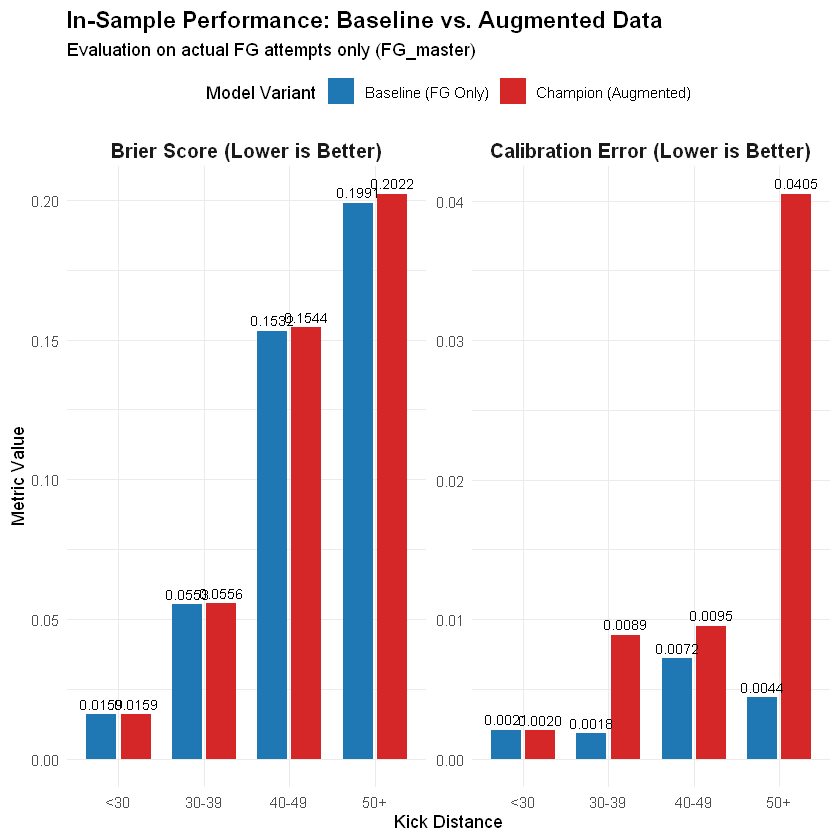

In [18]:
# 1. Create the Data Frame from your results
bin_results <- bin_metrics

# 2. Prepare Data for Plotting (Pivot Longer)
# Ensure the bins are ordered correctly
bin_results$dist_bin <- factor(bin_results$dist_bin, levels = c("<30", "30-39", "40-49", "50+"))

plot_data <- bin_results %>%
  pivot_longer(
    cols = c(base_brier, champ_brier, base_calib, champ_calib),
    names_to = c("model", "metric"),
    names_sep = "_"
  ) %>%
  mutate(
    model_label = ifelse(model == "base", "Baseline (FG Only)", "Champion (Augmented)"),
    metric_label = ifelse(metric == "brier", "Brier Score (Lower is Better)", "Calibration Error (Lower is Better)")
  )

# 3. Generate the Plot
ggplot(plot_data, aes(x = dist_bin, y = value, fill = model_label)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  facet_wrap(~metric_label, scales = "free_y") +
  scale_fill_manual(values = c("Baseline (FG Only)" = "#1f77b4", "Champion (Augmented)" = "#d62728")) +
  labs(
    title = "In-Sample Performance: Baseline vs. Augmented Data",
    subtitle = "Evaluation on actual FG attempts only (FG_master)",
    x = "Kick Distance",
    y = "Metric Value",
    fill = "Model Variant"
  ) +
  geom_text(aes(label = sprintf("%.4f", value)), 
            position = position_dodge(width = 0.8), 
            vjust = -0.5, size = 3) +
  theme_minimal() +
  theme(
    legend.position = "top",
    strip.text = element_text(size = 12, face = "bold"),
    plot.title = element_text(face = "bold", size = 14)
  )

In [19]:
# --- Experiment Grid 3: Threshold-Based Pseudo-Labels ---

experiment_grid_3 <- tibble::tribble(
  ~variant_id,              ~include_pat, ~w_pat, ~include_non, ~non_pi_cutoff, ~w_non_type, ~w_non_fixed, ~non_xfg_threshold, ~non_dist_filter,

  # --- SECTION A: PAT ANCHORS ---
  "pat_w0.10",              TRUE,         0.10,   FALSE,        NA,             NA,          NA,           NA,                 NA,
  "pat_w0.15",              TRUE,         0.15,   FALSE,        NA,             NA,          NA,           NA,                 NA,

  # --- SECTION B: NON-ATTEMPTS (Threshold Pseudo-Labels) ---
  # Logic: If xFG > threshold, kick_made = 1, else 0. 
  # Weight is fixed (0.1 or 0.05). Filter > 33y.
  
  # Aggressive (Threshold 0.50) - Treats toss-ups as Makes
  "non_th0.50_w0.10",       FALSE,        NA,     TRUE,         0.20,           "fixed",     0.10,         0.50,               ">33",
  
  # Moderate (Threshold 0.70) - Treats likely kicks as Makes
  "non_th0.70_w0.10",       FALSE,        NA,     TRUE,         0.20,           "fixed",     0.10,         0.70,               ">33",
  
  # Conservative (Threshold 0.90) - Treats almost everything as Misses (Hard Negatives)
  "non_th0.90_w0.10",       FALSE,        NA,     TRUE,         0.20,           "fixed",     0.10,         0.90,               ">33",
  
  # Low Weight Check (0.05)
  "non_th0.70_w0.05",       FALSE,        NA,     TRUE,         0.20,           "fixed",     0.05,         0.70,               ">33",

  # --- SECTION C: COMBINATIONS ---
  # PAT Anchor (0.15) + Pseudo-Labels
  
  # Combo 1: PAT + Moderate Threshold
  "combo_pat0.15_th0.70",   TRUE,         0.15,   TRUE,         0.20,           "fixed",     0.10,         0.70,               ">33",
  
  # Combo 2: PAT + Conservative Threshold (Hard Negatives)
  "combo_pat0.15_th0.90",   TRUE,         0.15,   TRUE,         0.20,           "fixed",     0.10,         0.90,               ">33",
  
  # Combo 3: "Light" Combo (Low weights on both to preserve FG signal)
  "combo_pat0.10_th0.70_w0.05", TRUE,     0.10,   TRUE,         0.20,           "fixed",     0.05,         0.70,               ">33"
)


# Print summary
cat(sprintf("Loaded Experiment Grid 3 with %d variants.\n", nrow(experiment_grid_3)))
print(experiment_grid_3 %>% dplyr::select(variant_id, non_xfg_threshold, w_non_fixed))

Loaded Experiment Grid 3 with 9 variants.
# A tibble: 9 × 3
  variant_id                 non_xfg_threshold w_non_fixed
  <chr>                                  <dbl>       <dbl>
1 pat_w0.10                               NA         NA   
2 pat_w0.15                               NA         NA   
3 non_th0.50_w0.10                         0.5        0.1 
4 non_th0.70_w0.10                         0.7        0.1 
5 non_th0.90_w0.10                         0.9        0.1 
6 non_th0.70_w0.05                         0.7        0.05
7 combo_pat0.15_th0.70                     0.7        0.1 
8 combo_pat0.15_th0.90                     0.9        0.1 
9 combo_pat0.10_th0.70_w0.05               0.7        0.05


In [20]:
# --- Single Variant In-Sample Playground (V1: Expanded Metrics & FG Evaluation) ---

# 1. Setup & Directories
output_dir <- file.path(augmented_reports_dir, "custom_variant_results_v1")
if (!dir.exists(output_dir)) dir.create(output_dir, recursive = TRUE)

# Check dependencies
stopifnot(exists("FG_master"), exists("PAT_master"), exists("NON_master"), 
          exists("experiment_grid_3"), exists("m1_formula"), exists("calc_metrics"))


# Load Baseline Metrics for Deltas
baseline_path <- file.path(augmented_reports_dir, 'baseline_fg_insample_metrics.csv')
baseline_metrics <- if (file.exists(baseline_path)) readr::read_csv(baseline_path, show_col_types = FALSE) else NULL

# Container for results
v1_results <- list()

# Suppress warnings for loop
options(warn = -1)

cat(sprintf("--- Starting V1 Experiment Loop: %d Variants ---\n", nrow(experiment_grid_3)))

# 2. Iteration
for (i in 1:nrow(experiment_grid_3)) {
  cfg <- experiment_grid_3[i, ]
  vid <- cfg$variant_id
  
  # Skip baseline if present (it's just a reference row)
  if (vid == "baseline_v1") next
  
  cat(sprintf("\n>>> Processing %d/%d: %s\n", i, nrow(experiment_grid_3), vid))
  flush.console()
  
  tryCatch({
    start_time <- Sys.time()
    
    # --- A. Build Augmented Data ---
    
    # 1. FG Data (Base)
    train_fg <- FG_master %>% dplyr::mutate(obs_weight = 1.0, src = "FG")
    
    # 2. PAT Data (Anchor)
    train_pats <- if (isTRUE(cfg$include_pat)) {
      PAT_master %>% 
        dplyr::mutate(obs_weight = as.numeric(cfg$w_pat), src = "PAT")
    } else { tibble::tibble() }
    
    # 3. NON Data (Pseudo-Label Logic)
    train_non <- if (isTRUE(cfg$include_non)) {
      non_filtered <- NON_master %>% 
        dplyr::filter(p_hat_multinom >= cfg$non_pi_cutoff)
      
      # Distance Filter
      if (!is.na(cfg$non_dist_filter)) {
        if (cfg$non_dist_filter == ">33") non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 33)
        else if (cfg$non_dist_filter == "<50") non_filtered <- non_filtered %>% dplyr::filter(kick_distance < 50)
      }
      
      # Apply Pseudo-Labels & Weights
      non_filtered %>%
        dplyr::mutate(
          # THE CORE LOGIC: Threshold-based labelling
          kick_made = ifelse(xfg_pred >= cfg$non_xfg_threshold, 1L, 0L),
          obs_weight = as.numeric(cfg$w_non_fixed),
          src = "NON"
        )
    } else { tibble::tibble() }
    
    # 4. Combine
    train_aug <- dplyr::bind_rows(train_fg, train_pats, train_non) %>%
      dplyr::select(-dplyr::starts_with("dist_bs_")) %>% # Remove old splines
      dplyr::filter(!is.na(obs_weight), is.finite(obs_weight), obs_weight > 1e-6)
    
    # --- B. Feature Engineering (Splines & Pooling) ---
    
    # Regenerate Splines
    aug_splines <- build_distance_bs(train_aug$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
    train_aug <- dplyr::bind_cols(train_aug, aug_splines)
    
    cat(sprintf("   Data: %d rows (FG=%d, PAT=%d, NON=%d)\n", 
                nrow(train_aug), nrow(train_fg), nrow(train_pats), nrow(train_non)))
    
    # Pool Sparse Levels (Train = Augmented, Test = Dummy FG to verify mapping)
    # We effectively treat the Augmented set as the training universe
    pooled_data <- pool_sparse_levels(train_aug, FG_master[1:5,], id_col = "kicker_player_id", min_n = 5L)
    train_pooled <- pooled_data$train
    
    # --- C. Fit Model ---
    fit_aug <- glmmTMB::glmmTMB(
      m1_formula,
      data = train_pooled,
      family = binomial(link = "logit"),
      weights = obs_weight,
      control = ctrl
    )
    
    # --- D. Predict (In-Sample Inference on FG_master) ---
    # We need to predict on the *Original* FG_master to see how the model views real kicks now
    # We must apply the SAME pooling logic to FG_master
    fg_eval <- FG_master
    
    # Handle Levels in Eval Set based on Training Set
    train_levels <- levels(train_pooled$kicker_player_id)
    fg_eval$kicker_player_id <- as.character(fg_eval$kicker_player_id)
    fg_eval$kicker_player_id <- ifelse(fg_eval$kicker_player_id %in% train_levels, 
                                       fg_eval$kicker_player_id, "REPL")
    fg_eval$kicker_player_id <- factor(fg_eval$kicker_player_id, levels = train_levels)
    
    # Ensure splines exist
    if(!"dist_bs_1" %in% names(fg_eval)) {
       eval_splines <- build_distance_bs(fg_eval$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
       fg_eval <- dplyr::bind_cols(fg_eval, eval_splines)
    }

    # --- CRITICAL FIX: Add dummy weight for prediction ---
    fg_eval$obs_weight <- 1.0
    
    # Predict
    p_insample <- predict_safe(fit_aug, fg_eval)
    
    # --- E. Save Predictions & Calculate Metrics ---
    
    # Save Predictions
    preds_df <- fg_eval %>%
      dplyr::select(kick_made, kick_distance, season, kicker_player_id) %>%
      dplyr::mutate(p_hat = p_insample, variant = vid, src = "FG")
    
    readr::write_csv(preds_df, file.path(output_dir, paste0(vid, "_predictions.csv")))
    
    # Calculate Metrics (Strictly on FG)
    metrics <- calc_metrics(preds_df$kick_made, preds_df$p_hat, set_name = "in_sample") %>%
      dplyr::mutate(variant = vid, .before = 1)
    
    # Calculate Deltas
    if (!is.null(baseline_metrics)) {
      metrics <- metrics %>%
        dplyr::mutate(
          auc_delta     = auc - baseline_metrics$auc,
          brier_delta   = brier - baseline_metrics$brier,
          calib_delta   = calib_error - baseline_metrics$calib_error,
          f1_delta      = f1_score - baseline_metrics$f1_score
        )
    }
    
    v1_results[[vid]] <- metrics
    
    end_time <- Sys.time()
    cat(sprintf("   Completed in %.2f secs. AUC Delta: %.5f | Calib Delta: %.5f\n", 
                difftime(end_time, start_time, units="secs"), 
                metrics$auc_delta, metrics$calib_delta))
    
  }, error = function(e) {
    cat(sprintf("   !!! Error in %s: %s\n", vid, conditionMessage(e)))
  })
}

options(warn = 0)

# --- 3. Compile & Save Summary ---
final_v1_results <- dplyr::bind_rows(v1_results) %>%
  dplyr::arrange(desc(auc))

#Add baseline row from file if exists
if (!is.null(baseline_metrics)) {
  final_v1_results <- dplyr::bind_rows(baseline_metrics, final_v1_results)
}

output_path <- file.path(augmented_reports_dir, "v1_pseudo_label_results.csv")
readr::write_csv(final_v1_results, output_path)

cat("\n--- V1 Experiment Results (Top Variants by Calibration Improvement) ---\n")

# Show negative calib_delta (improvement) first
print(final_v1_results %>% 
      dplyr::arrange(calib_delta) %>% 
      dplyr::select(variant, auc, brier, calib_error, calib_delta))

--- Starting V1 Experiment Loop: 9 Variants ---

>>> Processing 1/9: pat_w0.10
   Data: 23071 rows (FG=10432, PAT=12639, NON=0)
   Completed in 16.01 secs. AUC Delta: -0.00213 | Calib Delta: 0.00042

>>> Processing 2/9: pat_w0.15
   Data: 23071 rows (FG=10432, PAT=12639, NON=0)
   Completed in 16.57 secs. AUC Delta: -0.00292 | Calib Delta: 0.00023

>>> Processing 3/9: non_th0.50_w0.10
   Data: 12444 rows (FG=10432, PAT=0, NON=2012)
   Completed in 11.17 secs. AUC Delta: -0.00076 | Calib Delta: 0.00092

>>> Processing 4/9: non_th0.70_w0.10
   Data: 12444 rows (FG=10432, PAT=0, NON=2012)
   Completed in 11.12 secs. AUC Delta: 0.00094 | Calib Delta: -0.00461

>>> Processing 5/9: non_th0.90_w0.10
   Data: 12444 rows (FG=10432, PAT=0, NON=2012)
   Completed in 12.03 secs. AUC Delta: -0.00386 | Calib Delta: -0.00046

>>> Processing 6/9: non_th0.70_w0.05
   Data: 12444 rows (FG=10432, PAT=0, NON=2012)
   Completed in 11.49 secs. AUC Delta: 0.00051 | Calib Delta: -0.00260

>>> Processing 7/9: 

In [21]:
# --- Single Variant In-Sample Playground (V2: Expanded Metrics & FG Evaluation) ---

# 1. >>> DEFINE YOUR VARIANT PARAMETERS TO TEST HERE <<<
include_pat_param          <- TRUE
pat_weight_param           <- 0.15        # Continuous weight (e.g., 0.15)

include_non_param          <- TRUE
non_pi_cutoff_param        <- 0.25        # Min probability
non_fixed_weight_param     <- 0.15       # Weight for "fixed" mode
non_xfg_threshold_param    <- 0.5    # Threshold for Pseudo-Labeling
non_dist_filter_param      <- ">33"      # Distance filter
non_play_type_filter_param <- NA         # Play type filter
w_non_type_param           <- "fixed"    # "fixed" or "xfg_pred"


insample_baseline_metrics_path <- file.path(augmented_reports_dir, 'baseline_fg_insample_metrics.csv')
if (!file.exists(insample_baseline_metrics_path)) {
  cat("Baseline metrics file not found. Comparison deltas will not be calculated.\n")
}

# 3. --- Build Config and Run Single Variant ---

vid <- paste(
  if (isTRUE(include_pat_param)) paste0("pat_w", pat_weight_param) else "",
  if (isTRUE(include_non_param)) {
    paste(
      "non",
      paste0("th", non_xfg_threshold_param * 100),
      if(w_non_type_param == "fixed") paste0("fixW", non_fixed_weight_param) else "xfgW",
      paste0("pi", non_pi_cutoff_param * 100),
      if (!is.na(non_dist_filter_param)) gsub(">", "dist", gsub("<=", "lte", non_dist_filter_param)) else "",
      sep = "_"
    )
  } else "",
  sep = "_"
) %>% stringr::str_replace_all("__", "_") %>% stringr::str_remove("^_|_$")

cat(sprintf("\n--- Running Single In-Sample Variant: %s ---\n", vid))

current_variant_predictions <- tryCatch({
  start_time <- Sys.time()
  
  # A. Build Augmented Training Data
  cat("Step 1: Building augmented training data...\n")
  flush.console()
  
  # FG Data
  train_df_w <- FG_master %>% dplyr::mutate(obs_weight = 1.0, src = "FG")
  
  # PAT Data
  train_pats <- if (isTRUE(include_pat_param)) {
    PAT_master %>% 
      dplyr::mutate(obs_weight = as.numeric(pat_weight_param), src = "PAT")
  } else { tibble::tibble() }

  # NON Data
  train_non <- if (isTRUE(include_non_param)) {
    non_filtered <- NON_master %>% dplyr::filter(p_hat_multinom >= non_pi_cutoff_param)
    
    # Distance Filter
    if (!is.na(non_dist_filter_param)) {
      if (non_dist_filter_param == ">33") non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 33)
      else if (non_dist_filter_param == "<=50") non_filtered <- non_filtered %>% dplyr::filter(kick_distance <= 50)
      else if (non_dist_filter_param == ">35") non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 35)
    }
    
    # Pseudo-Labeling Logic (Threshold)
    non_filtered %>%
      dplyr::mutate(
        # If xFG > Threshold, treat as MAKE (1), else MISS (0)
        kick_made = ifelse(xfg_pred >= non_xfg_threshold_param, 1L, 0L),
        
        # Weight Assignment
        obs_weight = dplyr::case_when(
            w_non_type_param == "fixed"    ~ as.numeric(non_fixed_weight_param), 
            w_non_type_param == "xfg_pred" ~ as.numeric(xfg_pred),
            TRUE ~ 0.0
        ),
        src = "NON"
      )
  } else { tibble::tibble() }
  
  # Combine
  train_full_aug <- dplyr::bind_rows(train_df_w, train_pats, train_non) %>%
    dplyr::select(-dplyr::starts_with("dist_bs_")) %>%
    dplyr::filter(!is.na(obs_weight), is.finite(obs_weight), obs_weight > 1e-6)
    
  # Regenerate Splines
  aug_splines <- build_distance_bs(train_full_aug$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
  train_full_aug <- dplyr::bind_cols(train_full_aug, aug_splines)

  cat(sprintf(" -> Generated dataset: %d rows (FG=%d, PAT=%d, NON=%d)\n",
              nrow(train_full_aug), nrow(train_df_w), nrow(train_pats), nrow(train_non)))
  flush.console()
  
  # B. Pool Sparse Kickers
  cat("Step 2: Pooling sparse kickers...\n")
  # Using dummy test set just to satisfy function signature
  dummy_test <- train_full_aug[1:5,] 
  pooled_data <- pool_sparse_levels(train_full_aug, dummy_test, id_col="kicker_player_id", min_n=5L)
  train_pooled <- pooled_data$train
  
  # C. Fit Model
  cat("Step 3: Fitting model...\n")
  flush.console()
    
  fit_aug <- glmmTMB::glmmTMB(
      m1_formula, 
      data = train_pooled, 
      family = binomial(link = "logit"), 
      weights = obs_weight, 
      control = ctrl
  )
  
  # D. Predict (In-Sample on Augmented Set)
  cat("Step 4: Generating predictions...\n")
  # Note: We predict on the *pooled* training data to get in-sample stats for the augmented set
  # If you strictly want FG metrics, we filter later.
  p_aug_insample <- predict_safe(fit_aug, train_pooled)
  
  # E. Result DataFrame
  cols_for_analysis <- c("kick_made", "src", "kick_distance", "season", "kicker_player_id", 
                         "game_seconds_remaining", "qtr")
                         
  predictions_df <- train_pooled %>%
    dplyr::select(dplyr::any_of(cols_for_analysis)) %>%
    dplyr::mutate(p_hat = p_aug_insample, variant = vid)
  
  end_time <- Sys.time()
  cat(sprintf("Variant %s completed in %.2f seconds.\n", vid, difftime(end_time, start_time, units = "secs")))
  flush.console()
  
  predictions_df

}, error = function(e) {
  cat(sprintf("\n*** ERROR in variant: %s ***\nMsg: %s\n", vid, conditionMessage(e)))
  NULL
})

# 4. --- Load Previous Results, Combine, Compare, and Save ---

output_subdir <- file.path(augmented_reports_dir, "custom_variant_results_v2")
if (!dir.exists(output_subdir)) dir.create(output_subdir, recursive = TRUE)

if (!is.null(current_variant_predictions)) {
  output_filename <- paste0(vid, "_predictions.csv")
  output_path <- file.path(output_subdir, output_filename)
  readr::write_csv(current_variant_predictions, output_path)
}

previous_preds_files <- list.files(output_subdir, pattern = "*_predictions.csv", full.names = TRUE)
all_predictions_df <- if (length(previous_preds_files) > 0) {
  purrr::map_dfr(previous_preds_files, readr::read_csv, show_col_types = FALSE)
} else { tibble::tibble() }

# METRICS Calculation (FG Only)
metrics_from_preds <- all_predictions_df %>%
  dplyr::filter(src == "FG", !is.na(p_hat), is.finite(p_hat)) %>%
  dplyr::group_by(variant) %>%
  dplyr::group_modify(~ calc_metrics(.x$kick_made, .x$p_hat, set_name = "in_sample")) %>%
  dplyr::ungroup()

if (exists("insample_baseline_metrics_path") && file.exists(insample_baseline_metrics_path)) {
    baseline_metrics_loaded <- readr::read_csv(insample_baseline_metrics_path, show_col_types = FALSE)
    metrics_from_preds <- dplyr::bind_rows(baseline_metrics_loaded, metrics_from_preds) %>%
        dplyr::distinct(variant, .keep_all = TRUE)
}

baseline_row <- metrics_from_preds %>% dplyr::filter(variant == "baseline_fg_insample")

if (nrow(baseline_row) > 0) {
    metrics_with_deltas <- metrics_from_preds %>%
      dplyr::mutate(
        auc_delta     = auc - baseline_row$auc,
        brier_delta   = brier - baseline_row$brier,
        calib_delta   = calib_error - baseline_row$calib_error,
        f1_delta      = f1_score - baseline_row$f1_score
      ) %>%
      dplyr::arrange(desc(auc))
      
    metrics_output_path <- file.path(augmented_reports_dir, "pseudo_labelling_metrics_expanded.csv")
    readr::write_csv(metrics_with_deltas, metrics_output_path)
    
    cat("\n--- Comparison of All Variants vs. Baseline (In-Sample FG Metrics) ---\n")
    print(metrics_with_deltas %>% 
            dplyr::select(variant, auc, auc_delta, brier, calib_error, calib_delta))
} else {
    print(metrics_from_preds)
}


--- Running Single In-Sample Variant: pat_w0.15_non_th50_fixW0.15_pi25_dist33 ---
Step 1: Building augmented training data...
 -> Generated dataset: 24860 rows (FG=10432, PAT=12639, NON=1789)
Step 2: Pooling sparse kickers...
Step 3: Fitting model...


Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"


Step 4: Generating predictions...
Variant pat_w0.15_non_th50_fixW0.15_pi25_dist33 completed in 18.48 seconds.

--- Comparison of All Variants vs. Baseline (In-Sample FG Metrics) ---
# A tibble: 11 × 6
   variant                           auc auc_delta brier calib_error calib_delta
   <chr>                           <dbl>     <dbl> <dbl>       <dbl>       <dbl>
 1 non_fixW0.1_pi20_dist33         0.808   2.98e-4 0.100     0.0111     -0.00440
 2 non_th70_fixW0.1_pi20_dist33    0.808   2.98e-4 0.100     0.0111     -0.00440
 3 baseline_fg_insample            0.807   0       0.101     0.0155      0      
 4 non_th75_xfgW_pi25_dist33       0.807  -5.34e-5 0.102     0.0230      0.00747
 5 pat_w0.1_non_fixW0.1_pi20_dist… 0.806  -1.80e-3 0.101     0.0119     -0.00362
 6 pat_w0.05_non_fixW0.05_pi20_di… 0.805  -2.17e-3 0.101     0.0122     -0.00335
 7 pat_w0.1_non_th75_fixW0.1_pi20… 0.804  -3.37e-3 0.101     0.00910    -0.00644
 8 pat_w0.15_non_th50_fixW0.15_pi… 0.803  -4.33e-3 0.102     0.0175   

In [22]:
# --- 3. Full In-Sample Evaluation (M0 vs M1 vs M3 Augmented) ---

cat("\n--- Running Full In-Sample Evaluation (Augmented Workflow ---\n")

# 1. Configuration: Champion Parameters (Explicitly Defined)
champ_params <- list(
  include_pat       = TRUE,
  w_pat             = 0.1,
  include_non       = TRUE,
  non_pi_cutoff     = 0.25,
  non_dist_filter   = 33,
  non_xfg_threshold = 1, 
  w_non_fixed       = 0.1
)

# Load Formulas if needed
m1_model_path <- file.path(models_dir, "m1", "m1_fg_B_logit.rds")
if (!file.exists(m1_model_path)) stop("M1 model not found.")
m1_formula <- formula(readRDS(m1_model_path))

m0_model_path <- file.path(models_dir, "m0", "m0_fg_B_logit.rds")
if (!file.exists(m0_model_path)) stop("M0 model not found.")
m0_formula <- formula(readRDS(m0_model_path))

# -------------------------------------------------------
# A. Prepare Data for M3 (The Augmented Champion)
# -------------------------------------------------------
cat("Building M3 Augmented Training Data...\n")

# 1. FG Base
train_fg <- FG_master %>% dplyr::mutate(obs_weight = 1.0, src = "FG")

# 2. PATs
train_pats <- if (champ_params$include_pat) {
  PAT_master %>% dplyr::mutate(obs_weight = champ_params$w_pat, src = "PAT")
} else { tibble::tibble() }

# 3. NONs
train_non <- if (champ_params$include_non) {
  NON_master %>% 
    # Using the canonical propensity column
    dplyr::filter(p_hat_multinom >= champ_params$non_pi_cutoff) %>%
    dplyr::filter(kick_distance > champ_params$non_dist_filter) %>% 
    dplyr::mutate(
      src = "NON",
      # Threshold Logic: Treat as MAKE if xFG >= 0.5
      kick_made = ifelse(xfg_pred >= champ_params$non_xfg_threshold, 1L, 0L),
      obs_weight = champ_params$w_non_fixed
    )
} else { tibble::tibble() }

# Diagnostic: Check mean xFG of included non-attempts
if(nrow(train_non) > 0) {
    cat(sprintf("Mean xFG of included NONs: %.3f\n", mean(train_non$xfg_pred)))
    cat(sprintf("Percentage labeled as MAKE: %.1f%%\n", mean(train_non$kick_made)*100))
    cat(sprintf("Total NONs included: %d\n", nrow(train_non)))
}

# 4. Combine & Clean
train_m3_raw <- dplyr::bind_rows(train_fg, train_pats, train_non) %>%
  dplyr::select(-dplyr::starts_with("dist_bs_")) %>% 
  dplyr::filter(obs_weight > 1e-6)

# 5. Regenerate Splines for M3
m3_splines <- build_distance_bs(train_m3_raw$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
train_m3_raw <- dplyr::bind_cols(train_m3_raw, m3_splines)

# 6. Pool Sparse Levels for M3
# Train = Augmented Set, Test = FG_master (Target Evaluation Set)
pool_m3 <- pool_sparse_levels(train_m3_raw, FG_master, id_col = "kicker_player_id", min_n = 5L)
train_m3_pooled <- pool_m3$train
eval_fg_for_m3  <- pool_m3$test
eval_fg_for_m3$obs_weight <- 1.0 

# -------------------------------------------------------
# B. Prepare Data for M0/M1
# -------------------------------------------------------
pool_base <- pool_sparse_levels(FG_master, FG_master[1:5,], id_col = "kicker_player_id", min_n = 5L)
train_fg_pooled <- pool_base$train

# -------------------------------------------------------
# C. Fit Models
# -------------------------------------------------------

# 1. M0: Distance Only
cat("Fitting M0 (Distance Only)...\n")
fit_m0_full <- glmmTMB::glmmTMB(formula = m0_formula, data = train_fg_pooled, family = binomial(link = "logit"), control = ctrl)

# 2. M1: Baseline
cat("Fitting M1 (Baseline)...\n")
fit_m1_full <- glmmTMB::glmmTMB(formula = m1_formula, data = train_fg_pooled, family = binomial(link = "logit"), control = ctrl)

# 3. M3: Augmented
cat("Fitting M3 (Augmented Champion)...\n")
fit_m3_full <- glmmTMB::glmmTMB(formula = m1_formula, data = train_m3_pooled, family = binomial(link = "logit"), weights = obs_weight, control = ctrl)

# -------------------------------------------------------
# D. Predict & Evaluate
# -------------------------------------------------------
cat("Generating predictions...\n")

p_m0_full <- predict_safe(fit_m0_full, train_fg_pooled)
p_m1_full <- predict_safe(fit_m1_full, train_fg_pooled)
p_m3_full <- predict_safe(fit_m3_full, eval_fg_for_m3)

# Metrics
res_m0_full <- calc_metrics(train_fg_pooled$kick_made, p_m0_full, set_name = "in_sample") %>% dplyr::mutate(Model = "M0 (Distance Only)", .before = 1)
res_m1_full <- calc_metrics(train_fg_pooled$kick_made, p_m1_full, set_name = "in_sample") %>% dplyr::mutate(Model = "M1 (Baseline)", .before = 1)
res_m3_full <- calc_metrics(eval_fg_for_m3$kick_made, p_m3_full, set_name = "in_sample") %>% dplyr::mutate(Model = "M3 (Augmented)", .before = 1)

# Compare
insample_comparison <- dplyr::bind_rows(res_m0_full, res_m1_full, res_m3_full) %>%
  dplyr::mutate(
    auc_delta   = auc - res_m1_full$auc,
    brier_delta = brier - res_m1_full$brier,
    calib_delta = calib_error - res_m1_full$calib_error
  )

cat("\n--- Final In-Sample Comparison Results ---\n")
print(insample_comparison)

# -------------------------------------------------------
# E. Save Results & Predictions
# -------------------------------------------------------

if(exists("augmented_reports_dir")) {
  readr::write_csv(insample_comparison, file.path(augmented_reports_dir, 'augmented_insample_comparison.csv'))
  
  fg_full_predictions <- FG_master %>%
    dplyr::mutate(
      pred_m0_full = p_m0_full,
      pred_m1_full = p_m1_full,
      pred_m3_full = p_m3_full
    )
  readr::write_csv(fg_full_predictions, file.path(augmented_reports_dir, 'fg_full_with_augmented_predictions.csv'))
  cat("Predictions saved to CSV.\n")
}


--- Running Full In-Sample Evaluation (Augmented Workflow ---


Building M3 Augmented Training Data...
Mean xFG of included NONs: 0.759
Percentage labeled as MAKE: 0.0%
Total NONs included: 1789
Fitting M0 (Distance Only)...
Fitting M1 (Baseline)...
Fitting M3 (Augmented Champion)...


Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"


Generating predictions...

--- Final In-Sample Comparison Results ---
# A tibble: 3 × 13
  Model set   brier logloss   auc calib_error accuracy precision recall f1_score
  <chr> <chr> <dbl>   <dbl> <dbl>       <dbl>    <dbl>     <dbl>  <dbl>    <dbl>
1 M0 (… in_s… 0.105   0.340 0.775     0.00684    0.863     0.865  0.997    0.926
2 M1 (… in_s… 0.101   0.325 0.807     0.0163     0.865     0.867  0.996    0.927
3 M3 (… in_s… 0.102   0.329 0.800     0.0157     0.865     0.868  0.996    0.927
# ℹ 3 more variables: auc_delta <dbl>, brier_delta <dbl>, calib_delta <dbl>
Predictions saved to CSV.


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


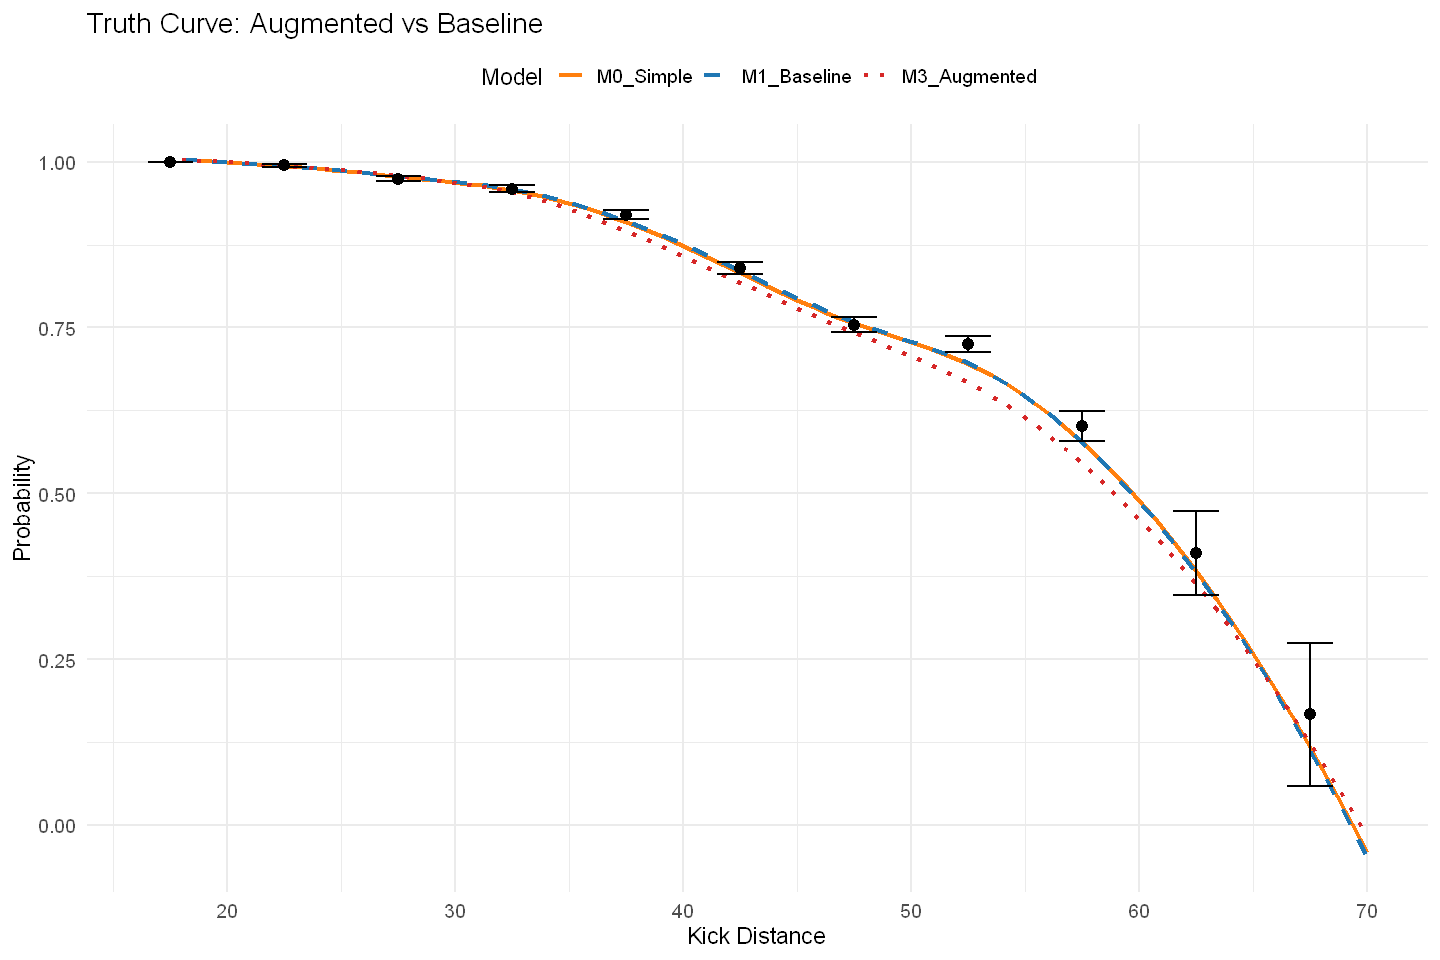

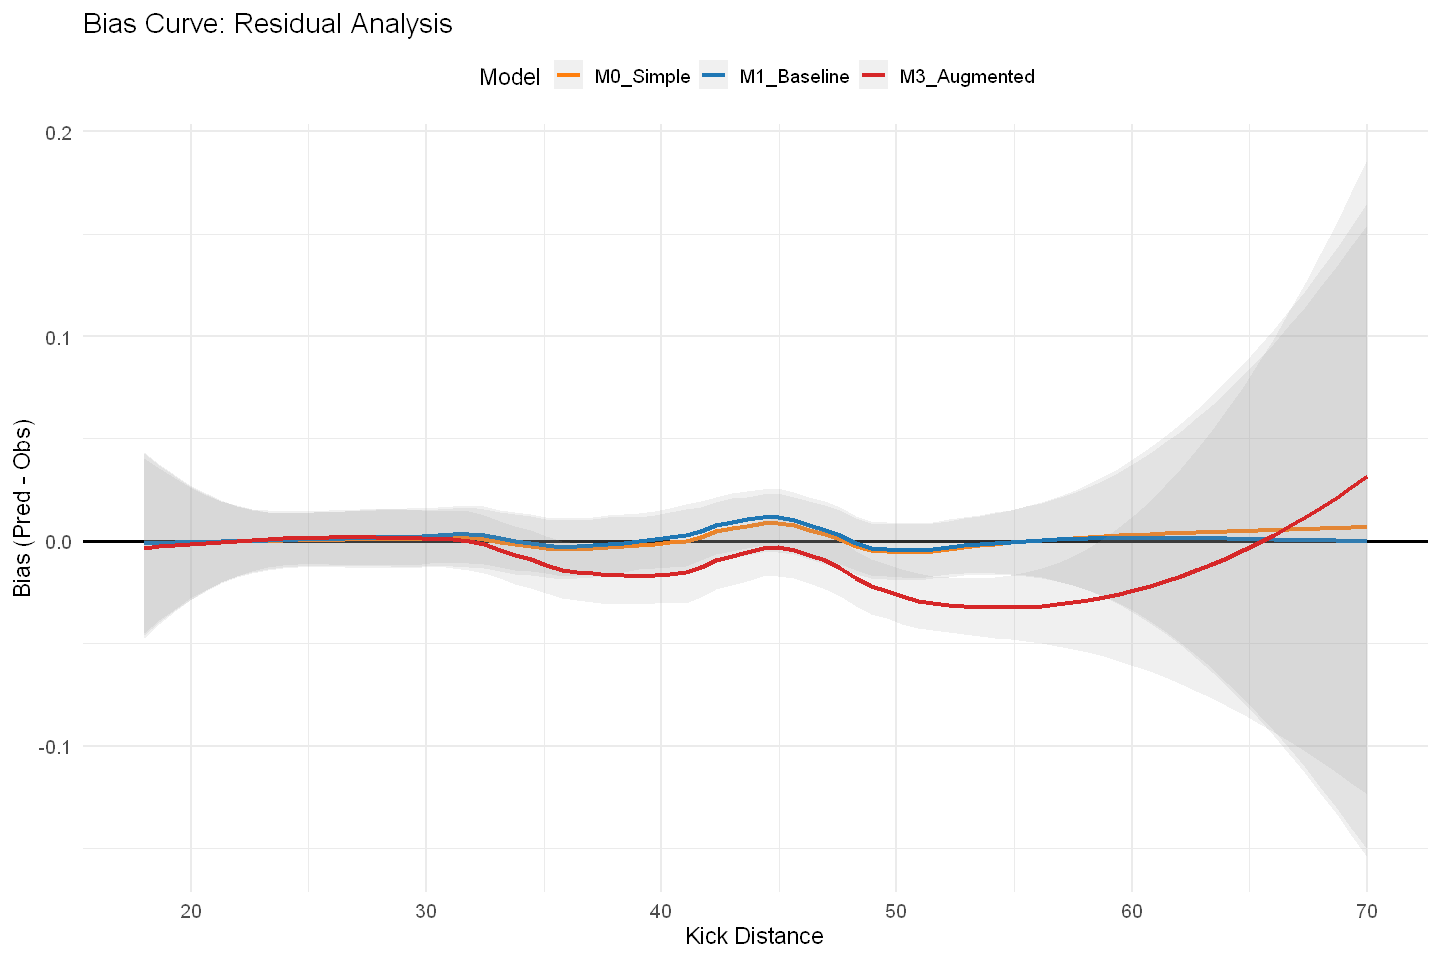

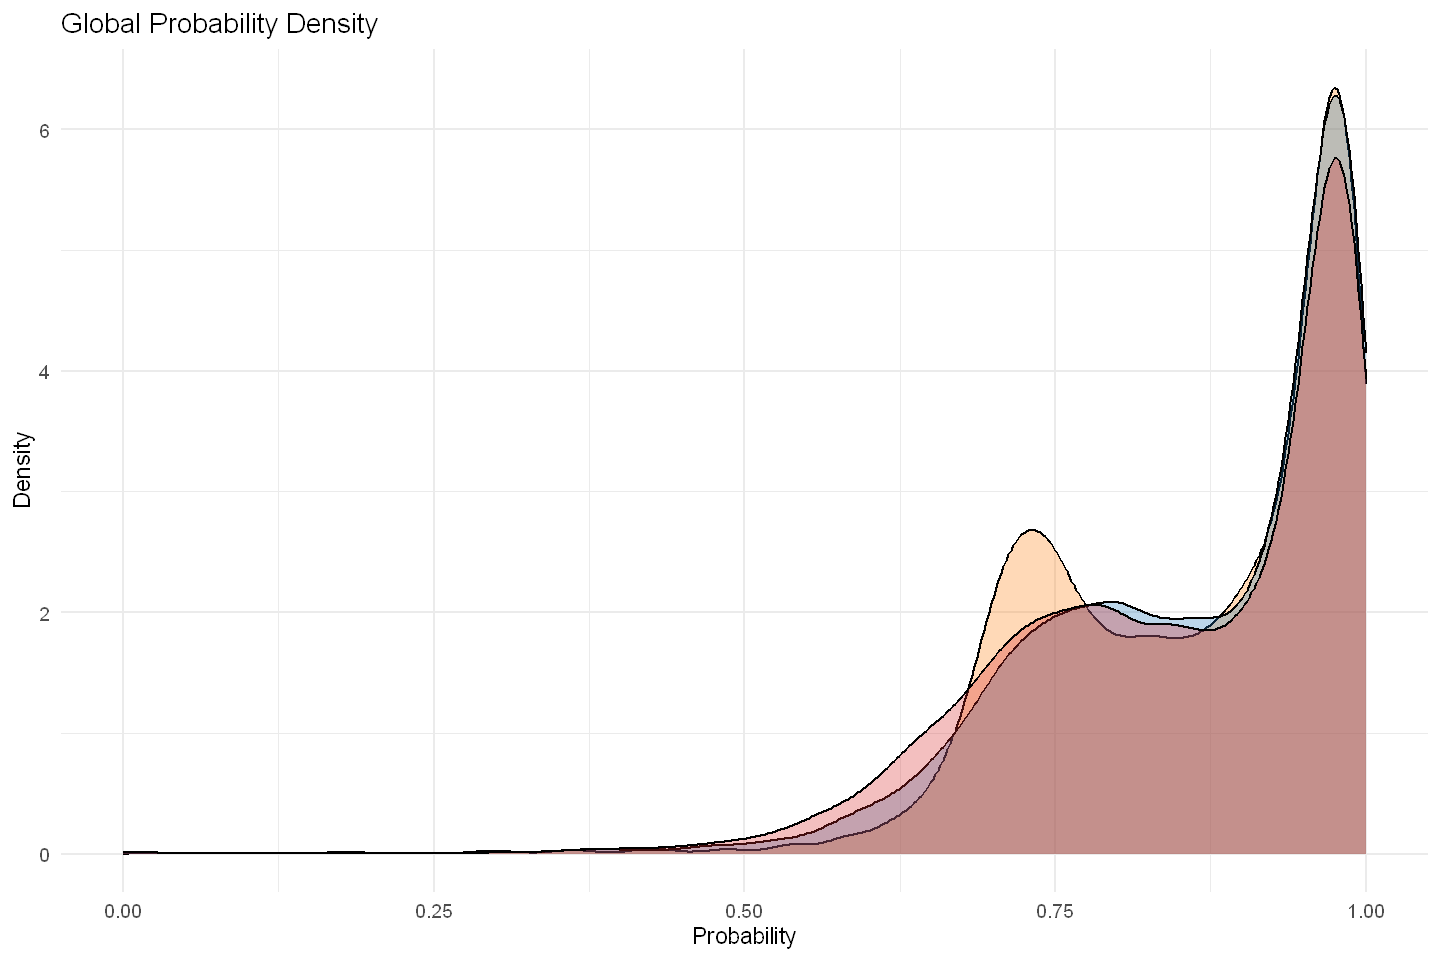

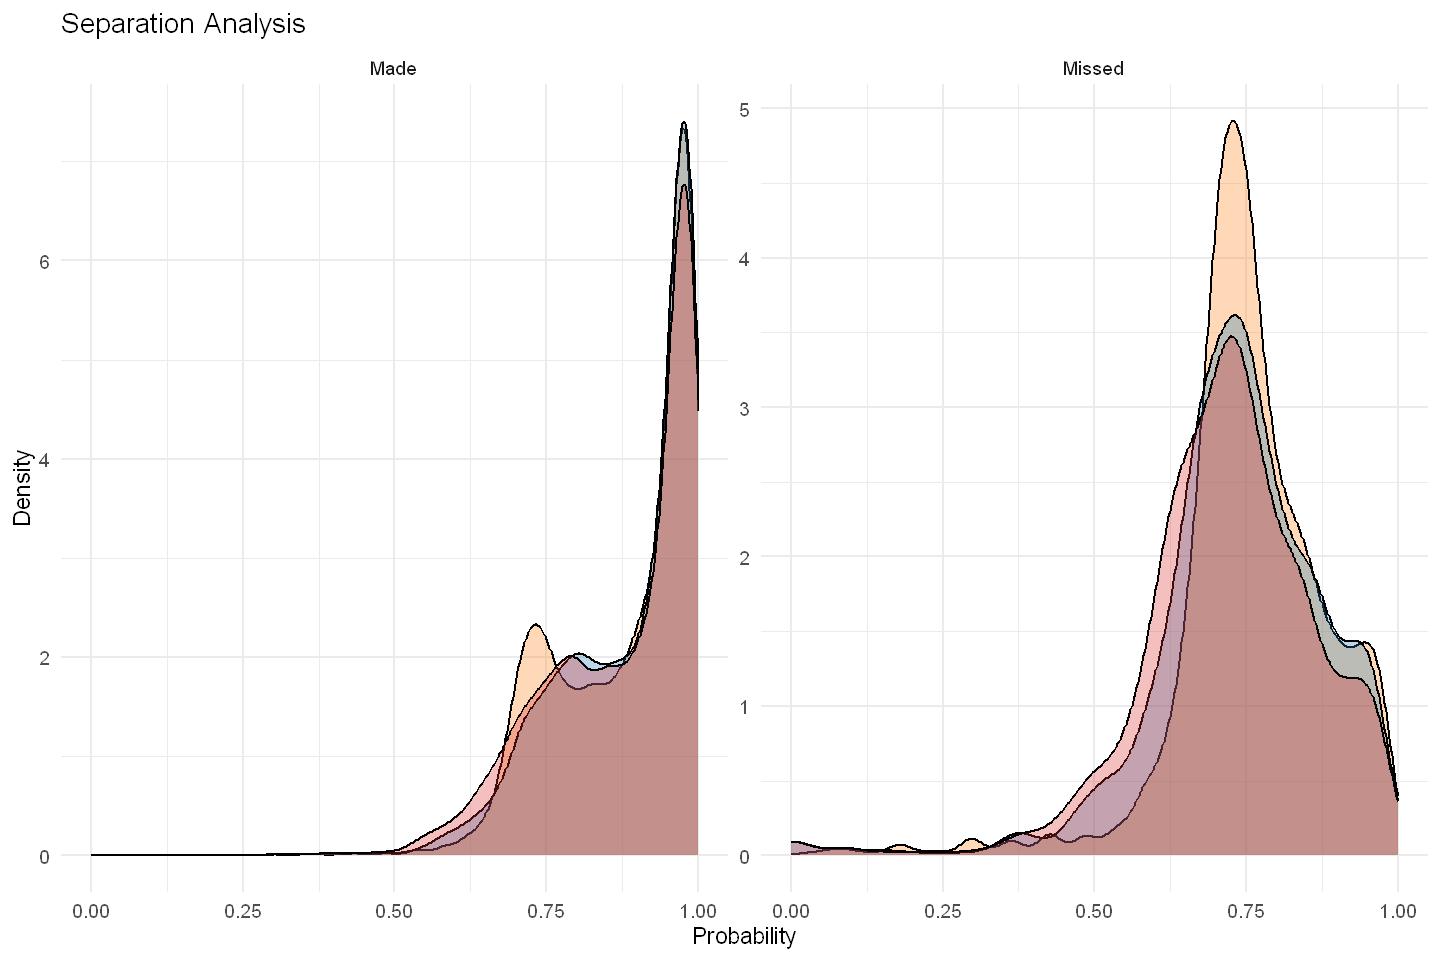

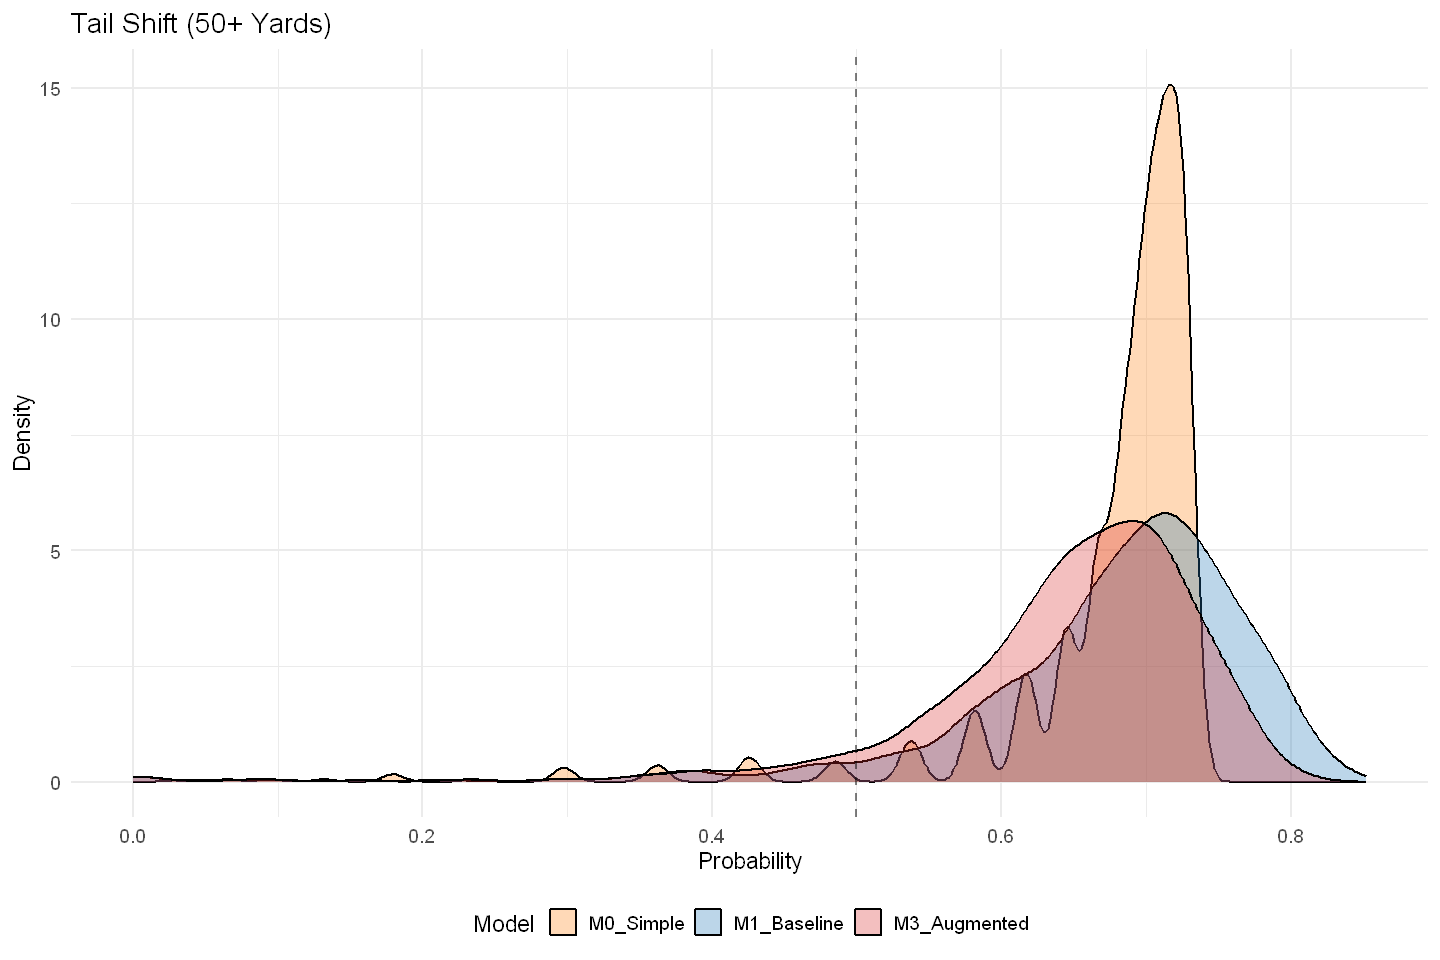

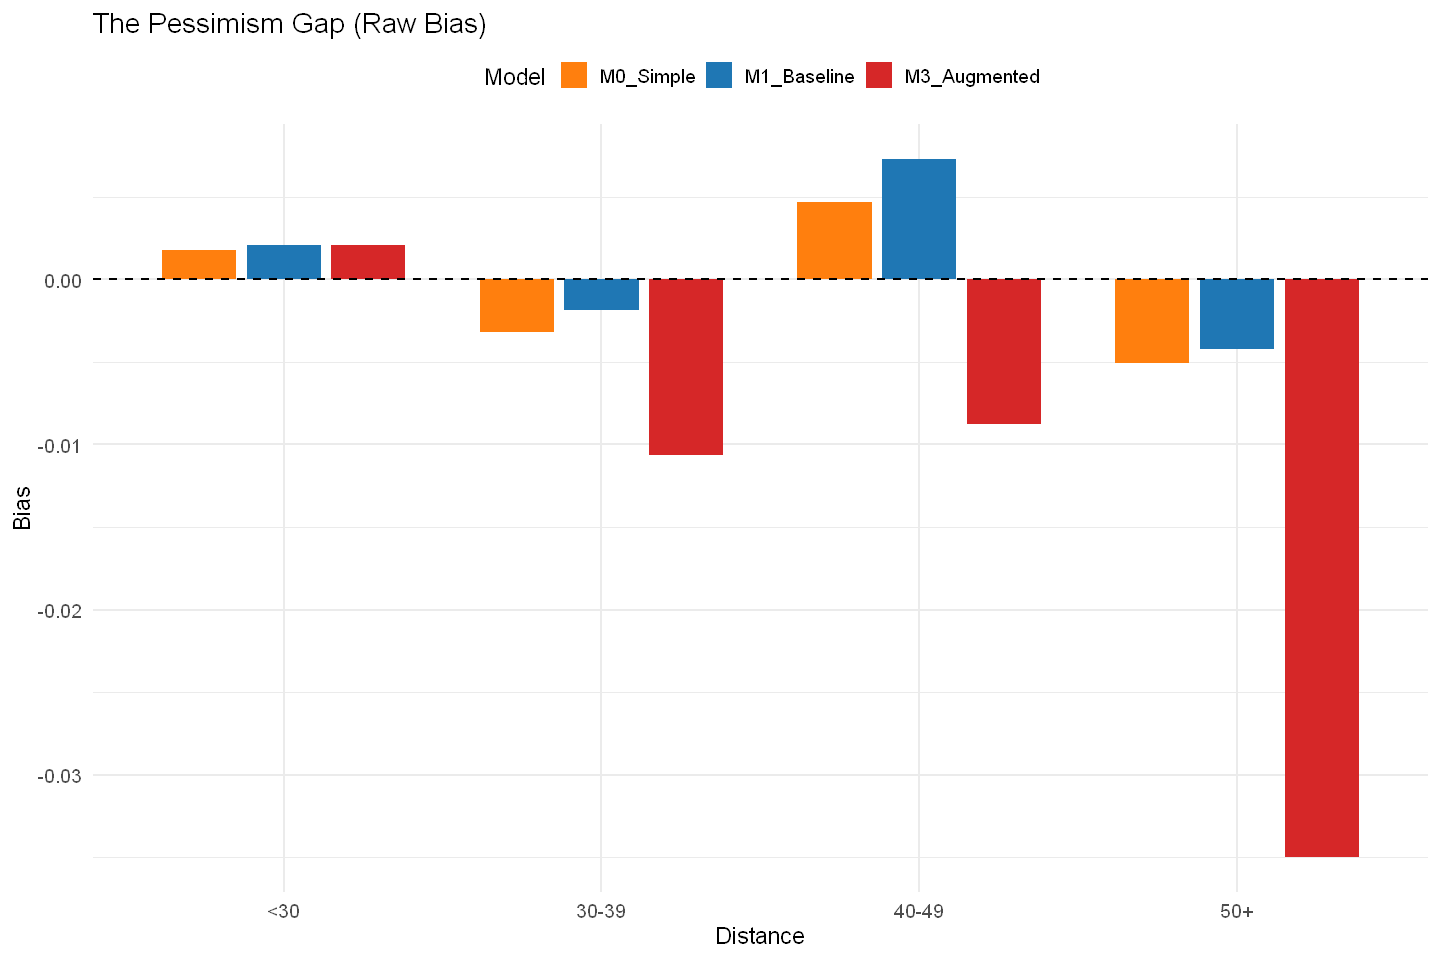

In [23]:
# ==============================================================================
# 1. Setup & Data Prep
# ==============================================================================

# Define Palette (M0 = Orange, M1 = Blue, M3 = Red)
cols <- c("M0_Simple"    = "#ff7f0e", # Orange
          "M1_Baseline"  = "#1f77b4", # Blue
          "M3_Augmented" = "#d62728") # Red

# A. Construct Comparison Dataframe
# We assume 'p_m0_full', 'p_m1_full', and 'p_m3_full' exist from the augmented eval step
comparison_df <- train_fg_pooled %>%
  dplyr::select(kick_made, kick_distance) %>%
  dplyr::mutate(
    M0_Simple    = p_m0_full,
    M1_Baseline  = p_m1_full, 
    M3_Augmented = p_m3_full, # The new Champion
    
    # Create Distance Bins
    dist_bin = dplyr::case_when(
      kick_distance < 30 ~ "<30",
      kick_distance < 40 ~ "30-39",
      kick_distance < 50 ~ "40-49",
      kick_distance >= 50 ~ "50+"
    )
  )

# Force Factor Order
comparison_df$dist_bin <- factor(comparison_df$dist_bin, levels = c("<30", "30-39", "40-49", "50+"))

# B. Calculate Detailed Metrics (Summary Table)
detailed_metrics <- comparison_df %>%
  dplyr::group_by(dist_bin) %>%
  dplyr::summarise(
    n = dplyr::n(),
    
    # Raw Bias (Signed) for Pessimism Gap
    bias_m0 = mean(M0_Simple) - mean(kick_made),
    bias_m1 = mean(M1_Baseline) - mean(kick_made),
    bias_m3 = mean(M3_Augmented) - mean(kick_made),
    
    .groups = "drop"
  )

# C. Prepare Plotting Data (Long Format)
plot_curve_data <- comparison_df %>%
  select(kick_distance, kick_made, M0_Simple, M1_Baseline, M3_Augmented) %>%
  pivot_longer(cols = c(M0_Simple, M1_Baseline, M3_Augmented), 
               names_to = "Model", values_to = "Prob")

dist_plot_data <- comparison_df %>%
  select(kick_made, kick_distance, M0_Simple, M1_Baseline, M3_Augmented, dist_bin) %>%
  pivot_longer(cols = c(M0_Simple, M1_Baseline, M3_Augmented), 
               names_to = "Model", values_to = "Probability") %>%
  mutate(Outcome = ifelse(kick_made == 1, "Made", "Missed"))

truth_binned <- comparison_df %>%
  mutate(bin_start = floor(kick_distance / 5) * 5) %>%
  group_by(bin_start) %>%
  summarise(n = n(), obs_prob = mean(kick_made),
            se = sqrt((obs_prob * (1 - obs_prob)) / n), .groups = "drop") %>%
  filter(n > 10)

# ==============================================================================
# 2. Plot Generation
# ==============================================================================

# --- Plot 1: The Truth Curve ---
p_truth <- ggplot() +
  geom_smooth(data = plot_curve_data, 
              aes(x = kick_distance, y = Prob, color = Model, linetype = Model), 
              method = "loess", span = 0.5, size = 1.2, se = FALSE) +
  geom_point(data = truth_binned, aes(x = bin_start + 2.5, y = obs_prob), size = 3) +
  geom_errorbar(data = truth_binned, aes(x = bin_start + 2.5, ymin = obs_prob - se, ymax = obs_prob + se), width = 2) +
  scale_color_manual(values = cols) +
  scale_linetype_manual(values = c("solid", "dashed", "dotted")) +
  labs(title = "Truth Curve: Augmented vs Baseline", x = "Kick Distance", y = "Probability") +
  theme_minimal(base_size = 14) + theme(legend.position = "top")

# --- Plot 2: The Bias Curve ---
p_bias <- ggplot(plot_curve_data %>% mutate(Residual = Prob - kick_made), 
                 aes(x = kick_distance, y = Residual, color = Model)) +
  geom_hline(yintercept = 0, color = "black", size = 1) +
  geom_smooth(method = "loess", span = 0.5, se = TRUE, alpha = 0.15, size = 1.2) +
  scale_color_manual(values = cols) +
  labs(title = "Bias Curve: Residual Analysis", x = "Kick Distance", y = "Bias (Pred - Obs)") +
  theme_minimal(base_size = 14) + theme(legend.position = "top")

# --- Plot 3: Global Density ---
p_dens_global <- ggplot(dist_plot_data, aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.3) +
  scale_fill_manual(values = cols) +
  labs(title = "Global Probability Density", x = "Probability", y = "Density") +
  theme_minimal(base_size = 14) + theme(legend.position = "none")

# --- Plot 4: Separation ---
p_dens_sep <- ggplot(dist_plot_data, aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.3) +
  facet_wrap(~Outcome, scales = "free_y") +
  scale_fill_manual(values = cols) +
  labs(title = "Separation Analysis", x = "Probability", y = "Density") +
  theme_minimal(base_size = 14) + theme(legend.position = "none")

# --- Plot 5: Tail Shift (50+) ---
p_dens_tail <- ggplot(dist_plot_data %>% filter(dist_bin == "50+"), aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.3) +
  scale_fill_manual(values = cols) +
  geom_vline(xintercept = 0.5, linetype="dashed", alpha=0.5) +
  labs(title = "Tail Shift (50+ Yards)", x = "Probability", y = "Density") +
  theme_minimal(base_size = 14) + theme(legend.position = "bottom")

# --- Plot 6: Pessimism Gap (Bar) ---
bias_bar_data <- detailed_metrics %>%
  select(dist_bin, starts_with("bias")) %>%
  pivot_longer(cols = -dist_bin, names_to = c("Metric", "Model"), names_sep = "_") %>%
  mutate(Model = case_when(Model == "m0" ~ "M0_Simple", Model == "m1" ~ "M1_Baseline", Model == "m3" ~ "M3_Augmented"))

p_bar_bias <- ggplot(bias_bar_data, aes(x = dist_bin, y = value, fill = Model)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
  scale_fill_manual(values = cols) +
  labs(title = "The Pessimism Gap (Raw Bias)", x = "Distance", y = "Bias") +
  theme_minimal(base_size = 14) + theme(legend.position = "top")

# ==============================================================================
# 3. Display
# ==============================================================================

options(repr.plot.width = 12, repr.plot.height = 8)
print(p_truth)
print(p_bias)
print(p_dens_global)
print(p_dens_sep)
print(p_dens_tail)
print(p_bar_bias)


--- Metrics Separated by Outcome (Augmented Comparison) ---
# A tibble: 6 × 7
  Model        Outcome_Label     n Mean_Prob  Brier LogLoss Calib_Error
  <chr>        <chr>         <int>     <dbl>  <dbl>   <dbl>       <dbl>
1 M0_Simple    Make (y=1)     8986     0.878 0.0271   0.139       0.122
2 M0_Simple    Miss (y=0)     1446     0.757 0.589    1.59        0.757
3 M1_Baseline  Make (y=1)     8986     0.883 0.0260   0.133       0.117
4 M1_Baseline  Miss (y=0)     1446     0.737 0.564    1.52        0.737
5 M3_Augmented Make (y=1)     8986     0.871 0.0311   0.149       0.129
6 M3_Augmented Miss (y=0)     1446     0.720 0.540    1.45        0.720


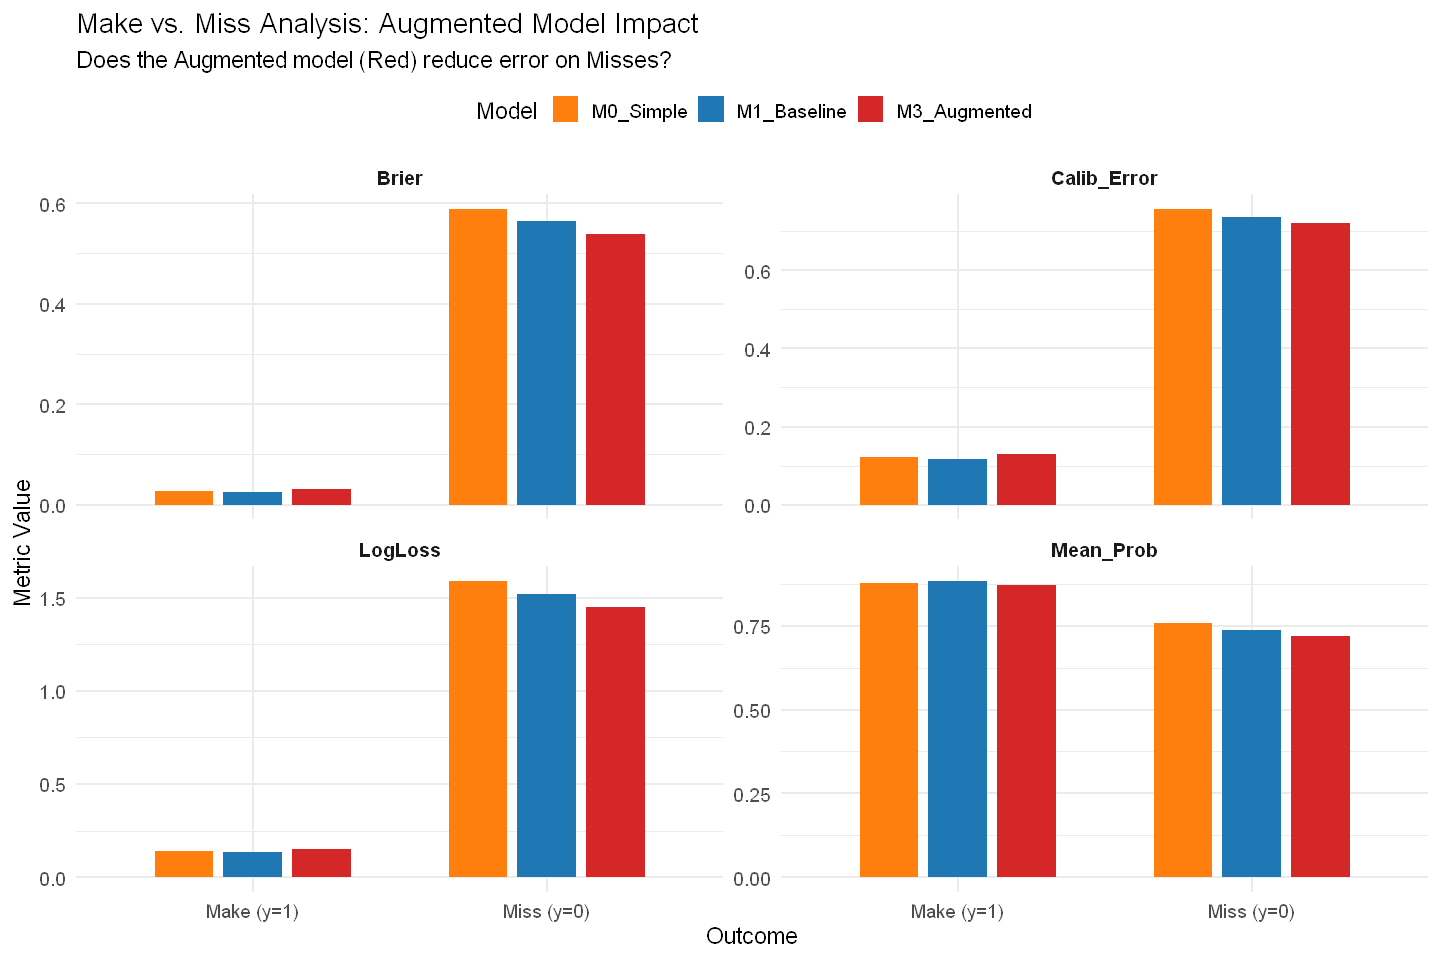

In [24]:

# ==============================================================================
# 1. Calculate Metrics by Outcome (M0, M1, M3)
# ==============================================================================

# Reshape data to Long format
# Assumes 'comparison_df' exists from the Augmented evaluation step
outcome_analysis <- comparison_df %>%
  dplyr::select(kick_made, M0_Simple, M1_Baseline, M3_Augmented) %>%
  tidyr::pivot_longer(
    cols = c(M0_Simple, M1_Baseline, M3_Augmented),
    names_to = "Model", 
    values_to = "Prob"
  ) %>%
  dplyr::mutate(Outcome_Label = ifelse(kick_made == 1, "Make (y=1)", "Miss (y=0)")) %>%
  dplyr::group_by(Model, Outcome_Label) %>%
  dplyr::summarise(
    n = dplyr::n(),
    
    # Confidence: How sure was the model?
    Mean_Prob = mean(Prob),
    
    # Brier: Prediction Error
    Brier = mean((kick_made - Prob)^2),
    
    # Log Loss: Penalizes Confidence on Wrong Answers
    LogLoss = -mean(ifelse(kick_made == 1, 
                           log(pmax(Prob, 1e-15)), 
                           log(pmax(1 - Prob, 1e-15)))),
    
    # Calibration Error: Absolute Bias
    Calib_Error = abs(mean(Prob) - mean(kick_made)),
    
    .groups = "drop"
  )

cat("\n--- Metrics Separated by Outcome (Augmented Comparison) ---\n")
print(outcome_analysis)

# ==============================================================================
# 2. Visualization
# ==============================================================================

# Define Palette (M0=Orange, M1=Blue, M3=Red)
cols <- c("M0_Simple"    = "#ff7f0e", 
          "M1_Baseline"  = "#1f77b4", 
          "M3_Augmented" = "#d62728")

# Reshape for Faceted Plotting
plot_outcome <- outcome_analysis %>%
  tidyr::pivot_longer(cols = c(Brier, LogLoss, Calib_Error, Mean_Prob), 
                      names_to = "Metric", values_to = "Value")

# Plot
p_outcome <- ggplot(plot_outcome, aes(x = Outcome_Label, y = Value, fill = Model)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.7), width = 0.6) +
  facet_wrap(~Metric, scales = "free_y") +
  scale_fill_manual(values = cols) +
  labs(
    title = "Make vs. Miss Analysis: Augmented Model Impact",
    subtitle = "Does the Augmented model (Red) reduce error on Misses?",
    x = "Outcome",
    y = "Metric Value"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    strip.text = element_text(face = "bold")
  )

print(p_outcome)

In [25]:
# --- Comprehensive Results Summary (Table & CSV) ---
# 1. Prepare Data
# We assume 'comparison_df' exists from the "Detailed Comparison" block.
# If strictly needed, we re-define the bins here to be safe.
summary_df <- comparison_df %>%
  dplyr::mutate(
    dist_bin = dplyr::case_when(
      kick_distance < 30 ~ "<30",
      kick_distance < 40 ~ "30-39",
      kick_distance < 50 ~ "40-49",
      kick_distance >= 50 ~ "50+"
    )
  )

# 2. Calculate All Metrics
# We calculate 'Raw Bias' (Pred - Actual) to quantify the "Pessimism" seen in the visuals.
# Negative Bias = Pessimistic (Under-predicting). Positive Bias = Optimistic.
detailed_metrics <- summary_df %>%
  dplyr::group_by(dist_bin) %>%
  dplyr::summarise(
    n = dplyr::n(),
    
    # A. Brier Score (Accuracy - Lower is Better)
    base_brier  = mean((kick_made - p_base)^2),
    champ_brier = mean((kick_made - p_champ)^2),
    brier_diff  = base_brier - champ_brier, # Positive = Champion Win
    
    # B. Calibration Error (Absolute Bias - Lower is Better)
    base_calib_err  = abs(mean(p_base) - mean(kick_made)),
    champ_calib_err = abs(mean(p_champ) - mean(kick_made)),
    calib_diff      = base_calib_err - champ_calib_err, # Positive = Champion Win
    
    # C. Pessimism/Shift Analysis (Raw Bias & Probabilities)
    # This numerically represents the "Left Shift" seen in the density plots
    obs_make_rate   = mean(kick_made),
    base_mean_prob  = mean(p_base),
    champ_mean_prob = mean(p_champ),
    
    # Raw Bias: (Pred - Actual). 
    # Look for Champ Bias to be more negative than Base Bias in 50+ bin
    base_raw_bias   = mean(p_base) - mean(kick_made),
    champ_raw_bias  = mean(p_champ) - mean(kick_made),
    
    .groups = "drop"
  ) %>%
  # Ensure logical order for the table
  dplyr::arrange(factor(dist_bin, levels = c("<30", "30-39", "40-49", "50+")))

# 3. Display & Save
cat("\n--- Comprehensive Model Performance Summary ---\n")
print(detailed_metrics, width = Inf)

# Save to CSV
output_file <- file.path(augmented_reports_dir, 'final_comprehensive_summary.csv')
readr::write_csv(detailed_metrics, output_file)
cat(sprintf("\nSummary table saved to: %s\n", output_file))

ERROR: [1m[33mError[39m in `dplyr::summarise()`:[22m
[1m[22m[36mℹ[39m In argument: `base_brier = mean((kick_made - p_base)^2)`.
[36mℹ[39m In group 1: `dist_bin = "30-39"`.
[1mCaused by error in `h()`:[22m
[33m![39m error in evaluating the argument 'x' in selecting a method for function 'mean': object 'p_base' not found


Predictions gathered from CSV.

--- Top 10 Kickers by Skill (FGOE vs M3 Augmented) ---
# A tibble: 10 × 10
   kicker_player_name Seasons Attempts Actual_Makes Exp_Makes_M3 FGOE_Total
   <chr>                <int>    <int>        <dbl>        <dbl>      <dbl>
 1 B.Aubrey                 2       83           77         68.3       8.70
 2 C.Dicker                 3      102           96         88.1       7.94
 3 J.Tucker                10      368          332        306.       25.8 
 4 G.Gano                   9      249          221        205.       15.7 
 5 C.Boswell               10      321          289        270.       19.3 
 6 N.Folk                   9      230          207        193.       13.7 
 7 C.McLaughlin             6      150          132        124.        7.85
 8 R.Gould                  8      251          227        215.       12.4 
 9 J.Sanders                7      218          190        179.       10.8 
10 C.Santos                10      252          223      

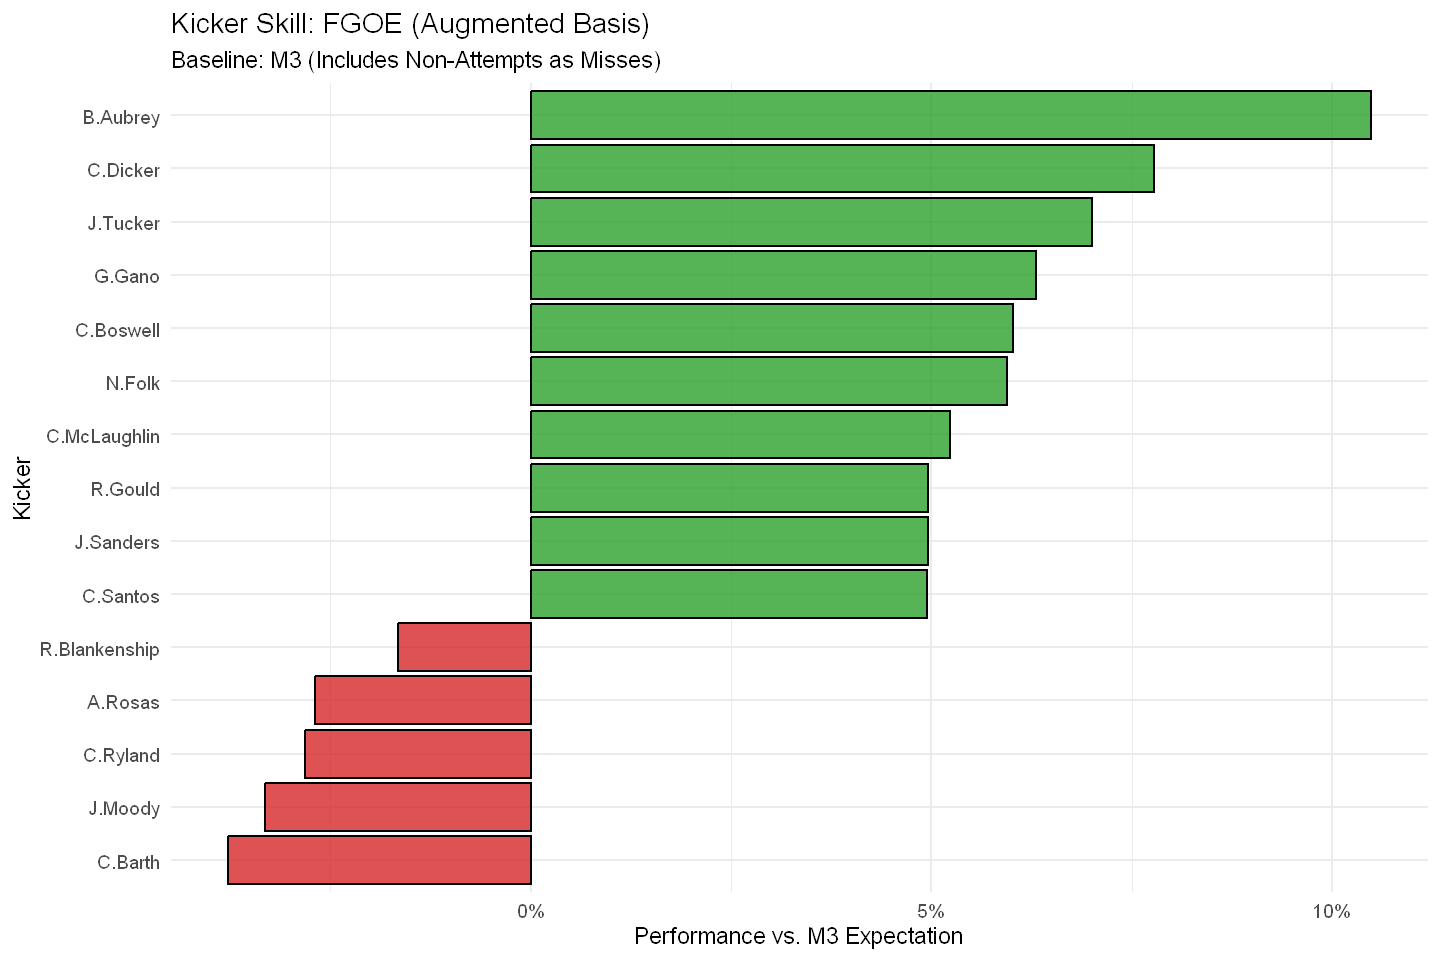

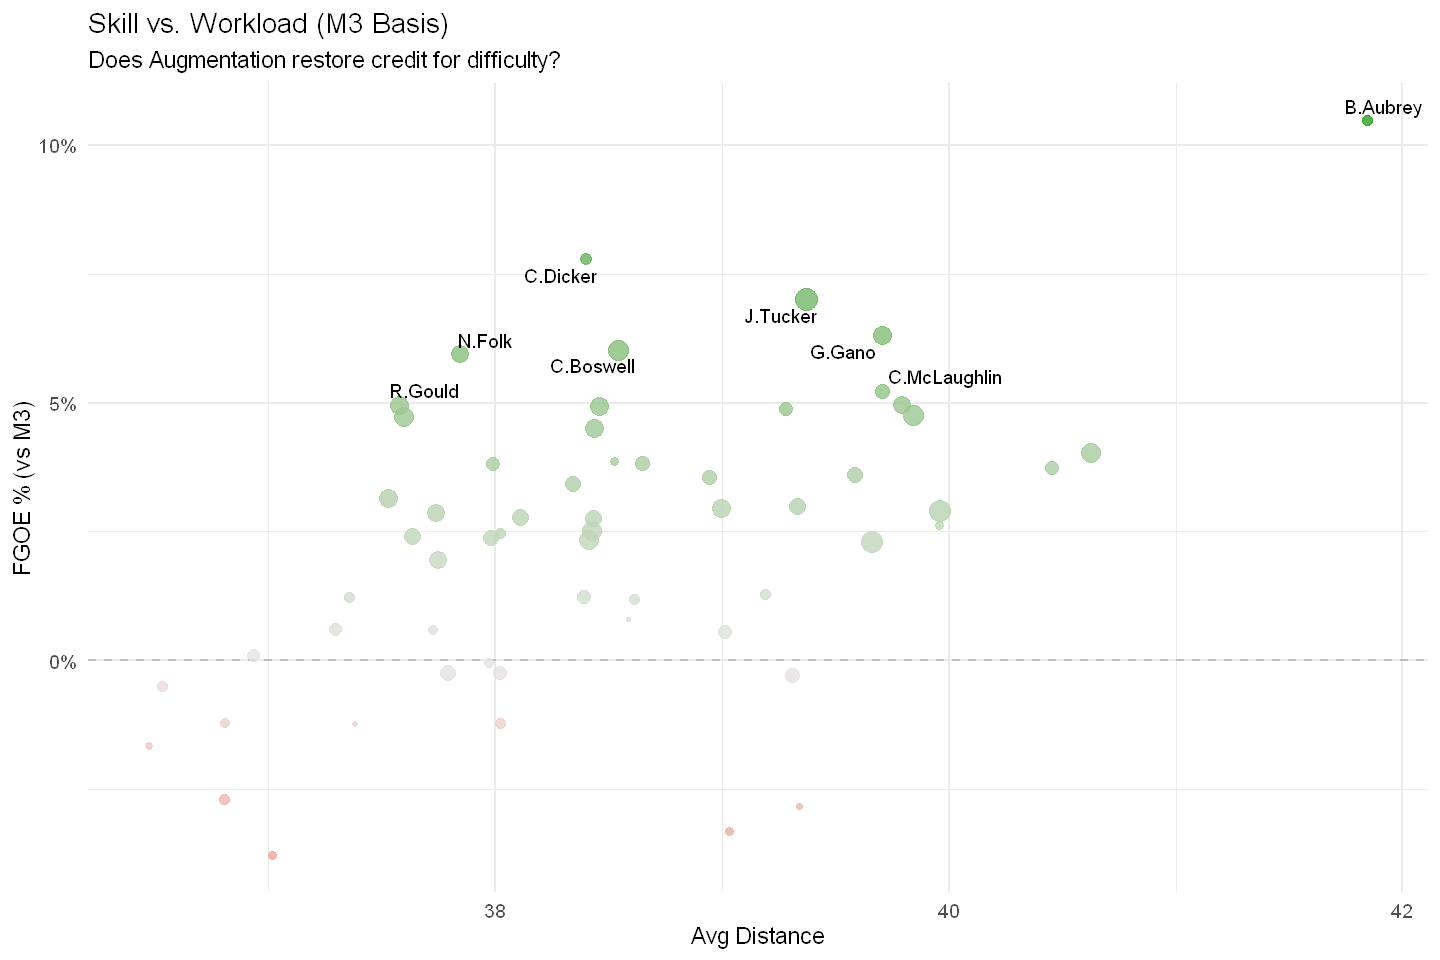

In [ ]:
# ==============================================================================
# 2. Calculate Skill Metrics (M3 Basis)
# ==============================================================================

# 1. Load Data
if(exists("augmented_reports_dir")) {
  fg_full_predictions <- readr::read_csv(file.path(augmented_reports_dir, 'fg_full_with_augmented_predictions.csv'), show_col_types = FALSE)
  cat("Predictions gathered from CSV.\n")
} else {
  stop("augmented_reports_dir not defined or file missing.")
}

# 2. Prepare Dataframe
analysis_df <- fg_full_predictions

# Ensure Names exist (fallback to ID if Name is missing)
if(!"kicker_player_name" %in% names(analysis_df)) {
  analysis_df$kicker_player_name <- analysis_df$kicker_player_id
}

# 3. Calculate FGOE vs M3
kicker_skill_m3 <- analysis_df %>%
  dplyr::group_by(kicker_player_name) %>%
  dplyr::summarise(
    Seasons = n_distinct(season),
    Attempts = n(),
    Actual_Makes = sum(kick_made),
    
    # Expectation: M3 (Augmented)
    # Note: Using 'pred_m3_full' as loaded from the CSV
    Exp_Makes_M3 = sum(pred_m3_full),
    
    # The Metric
    FGOE_Total = Actual_Makes - Exp_Makes_M3,
    FGOE_Per_Kick = FGOE_Total / Attempts,
    
    # Context
    Avg_Distance = mean(kick_distance),
    Actual_Pct = mean(kick_made),
    Exp_Pct_M3 = mean(pred_m3_full),
    
    .groups = "drop"
  ) %>%
  dplyr::filter(Attempts >= 50) %>%
  dplyr::arrange(desc(FGOE_Per_Kick))

cat("\n--- Top 10 Kickers by Skill (FGOE vs M3 Augmented) ---\n")
options(tibble.width = Inf)
print(head(kicker_skill_m3, 10))

# Compare Aubrey M2 vs M3 (Spot Check)
cat("\n--- The Aubrey Effect (M3) ---\n")
aubrey_m3 <- kicker_skill_m3 %>% filter(kicker_player_name == "B.Aubrey")
print(aubrey_m3)

# ==============================================================================
# 3. Visualizations
# ==============================================================================

# A. Leaderboard
top_kickers <- head(kicker_skill_m3, 10)
bottom_kickers <- tail(kicker_skill_m3, 5)
plot_leaderboard <- bind_rows(top_kickers, bottom_kickers) %>%
  mutate(
    Color = ifelse(FGOE_Per_Kick > 0, "#2ca02c", "#d62728"),
    Label = paste0(kicker_player_name, " (", round(FGOE_Per_Kick*100, 1), "%)")
  )

p_rank_3 <- ggplot(plot_leaderboard, aes(x = reorder(kicker_player_name, FGOE_Per_Kick), y = FGOE_Per_Kick, fill = Color)) +
  geom_bar(stat = "identity", color = "black", alpha = 0.8) +
  coord_flip() +
  scale_fill_identity() +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Kicker Skill: FGOE (Augmented Basis)",
    subtitle = "Baseline: M3 (Includes Non-Attempts as Misses)",
    x = "Kicker", y = "Performance vs. M3 Expectation"
  ) +
  theme_minimal(base_size = 14)

# B. Scatter (Skill vs Difficulty)
p_scatter_3 <- ggplot(kicker_skill_m3, aes(x = Avg_Distance, y = FGOE_Per_Kick)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey") +
  geom_point(aes(size = Attempts, color = FGOE_Per_Kick), alpha = 0.8) +
  ggrepel::geom_text_repel(data = head(kicker_skill_m3, 8), aes(label = kicker_player_name), size = 4) +
  scale_color_gradient2(low = "#d62728", mid = "grey90", high = "#2ca02c", midpoint = 0) +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Skill vs. Workload (M3 Basis)",
    subtitle = "Does Augmentation restore credit for difficulty?",
    x = "Avg Distance", y = "FGOE % (vs M3)"
  ) +
  theme_minimal(base_size = 14) + theme(legend.position = "none")

# Display
options(repr.plot.width = 12, repr.plot.height = 8)
print(p_rank_3)
print(p_scatter_3)

In [ ]:
# --- Prediction Distribution Analysis: Best V2 Variant vs. Baseline ---

# This cell identifies the best-performing variant from the "v2" experiments
# by reading the saved metrics file. It then loads the pre-saved prediction
# files for both the best variant and the baseline to plot and compare their
# prediction distributions without re-running any models.

# 1. --- Setup and Prerequisites ---
if (!"ggplot2" %in% installed) install.packages("ggplot2")
suppressPackageStartupMessages(library(ggplot2))

# Define paths for the metrics and prediction files
metrics_path <- file.path(augmented_reports_dir, "pseudo_labelling_metrics.csv")
output_subdir_v2 <- file.path(augmented_reports_dir, "custom_variant_results_v2")
insample_baseline_preds_path <- file.path(augmented_reports_dir, 'baseline_fg_insample_predictions.csv')

# Check that necessary files exist
if (!file.exists(metrics_path)) {
  stop("The main metrics file 'pseudo_labelling_metrics.csv' does not exist. Please run the experiment cell first.")
}
if (!file.exists(insample_baseline_preds_path)) {
  stop("The baseline predictions file 'baseline_fg_insample_predictions.csv' does not exist. Please run the baseline cell first.")
}


# 2. --- Identify the Best Performing V2 Variant from Saved Metrics---
cat("--- Step 1: Identifying the best performing V2 variant by AUC ---\n")

all_metrics <- readr::read_csv(metrics_path, show_col_types = FALSE)

best_variant_info <- all_metrics %>%
  dplyr::filter(variant != "baseline_fg_insample") %>% # Exclude the IN-SAMPLE baseline
  dplyr::arrange(desc(auc)) %>%
  dplyr::slice(1)

if (nrow(best_variant_info) == 0) {
  stop("No augmented variants found in the metrics file. Please run at least one experiment.")
}

best_variant_id <- best_variant_info$variant
cat(sprintf(" -> Best variant found: '%s' (AUC: %.4f)\n", best_variant_id, best_variant_info$auc))


# 3. --- Load Pre-Saved Predictions for Best Variant and Baseline ---
cat("\n--- Step 2: Loading pre-saved predictions ---\n")

# Path for the best variant's prediction file
best_variant_preds_path <- file.path(output_subdir_v2, paste0(best_variant_id, "_predictions.csv"))

if (!file.exists(best_variant_preds_path)) {
  stop(sprintf("Prediction file for the best variant '%s' not found.", best_variant_id))
}

# Load IN-SAMPLE baseline predictions
baseline_preds_df <- readr::read_csv(insample_baseline_preds_path, show_col_types = FALSE) %>%
  # The baseline script saves the variant name as 'model_variant', so we rename for consistency
  dplyr::rename(variant = model_variant)

# Load best variant's predictions and filter for FG data only
best_preds_df <- readr::read_csv(best_variant_preds_path, show_col_types = FALSE) %>%
  dplyr::filter(src == "FG")

# Combine for plotting
plot_data <- dplyr::bind_rows(best_preds_df, baseline_preds_df) %>%
  dplyr::filter(is.finite(p_hat))


# 4. --- Plot the Prediction Distributions ---
cat("\n--- Step 3: Plotting prediction distributions ---\n")

# Plot 1: Overlaid density plots
p1 <- ggplot(plot_data, aes(x = p_hat, fill = variant)) +
  geom_density(alpha = 0.5) +
  scale_fill_manual(values = c("skyblue", "salmon")) +
  labs(
    title = "Distribution of Predicted Probabilities (p_hat)",
    subtitle = "Comparing Baseline vs. Best Augmented Model (In-Sample on FGs)",
    x = "Predicted Probability (xFG)",
    y = "Density",
    fill = "Model Variant"
  ) +
  theme_minimal() +
  theme(legend.position = "top")

print(p1)

# Plot 2: Faceted histograms
p2 <- ggplot(plot_data, aes(x = p_hat)) +
  geom_histogram(aes(fill = variant), binwidth = 0.025, color = "white", alpha = 0.8) +
  facet_wrap(~ variant, ncol = 1, scales = "free_y") +
  scale_fill_manual(values = c("skyblue", "salmon")) +
  labs(
    title = "Faceted Histograms of Predicted Probabilities",
    subtitle = "A higher U-shape indicates a more confident model",
    x = "Predicted Probability (xFG)",
    y = "Count"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

print(p2)


ERROR: Error: The main metrics file 'pseudo_labelling_metrics.csv' does not exist. Please run the experiment cell first.


In [ ]:
# --- Analysis of Prediction Changes (Best V2 Variant vs. Baseline) ---

# This cell identifies the best-performing variant, loads the pre-saved
# prediction files for it and the IN-SAMPLE baseline, and then analyzes the specific
# predictions that changed between the models at a 0.5 threshold.

# 1. --- Prerequisites and File Paths ---
# This analysis now loads data directly from saved files.

# Define paths for the metrics and prediction files
metrics_path <- file.path(augmented_reports_dir, "pseudo_labelling_metrics.csv")
output_subdir_v2 <- file.path(augmented_reports_dir, "custom_variant_results_v2")
insample_baseline_preds_path <- file.path(augmented_reports_dir, 'baseline_fg_insample_predictions.csv')

# Check that necessary files exist
if (!file.exists(metrics_path)) {
  stop("The main metrics file 'pseudo_labelling_metrics.csv' does not exist. Please run the experiment cell first.")
}
if (!file.exists(insample_baseline_preds_path)) {
  stop("The baseline predictions file 'baseline_fg_insample_predictions.csv' does not exist. Please run the baseline cell first.")
}

# 2. --- Identify Best Variant and Load Predictions ---
cat("--- Step 1: Identifying best variant and loading predictions ---\n")

# Find the best-performing variant from the saved metrics file
all_metrics <- readr::read_csv(metrics_path, show_col_types = FALSE)
best_variant_info <- all_metrics %>%
  dplyr::filter(variant != "baseline_fg_insample") %>% # Exclude the IN-SAMPLE baseline
  dplyr::arrange(desc(auc)) %>%
  dplyr::slice(1)

if (nrow(best_variant_info) == 0) {
  stop("No augmented variants found in the metrics file. Please run at least one experiment.")
}
best_variant_id <- best_variant_info$variant
cat(sprintf(" -> Best variant found: '%s' (AUC: %.4f)\n", best_variant_id, best_variant_info$auc))

# Load IN-SAMPLE baseline predictions
# The baseline script saves the variant name as 'model_variant', so we rename for consistency
baseline_preds_df <- readr::read_csv(insample_baseline_preds_path, show_col_types = FALSE) %>%
  dplyr::rename(variant = model_variant)

# Load the best variant's predictions and filter for FG data only
best_variant_preds_path <- file.path(output_subdir_v2, paste0(best_variant_id, "_predictions.csv"))
if (!file.exists(best_variant_preds_path)) {
  stop(sprintf("Prediction file for the best variant '%s' not found.", best_variant_id))
}
best_preds_df <- readr::read_csv(best_variant_preds_path, show_col_types = FALSE) %>%
  dplyr::filter(src == "FG")

# Combine the two prediction sets
combined_preds <- dplyr::bind_rows(best_preds_df, baseline_preds_df)

# 3. --- Prepare Data for Change Analysis ---
cat("--- Step 2: Preparing data for change analysis ---\n")

# Add a unique identifier for each kick to ensure correct pivoting
combined_preds_with_id <- combined_preds %>%
  dplyr::group_by(variant) %>%
  dplyr::mutate(kick_id = dplyr::row_number()) %>%
  dplyr::ungroup()

# Pivot the data to have one row per kick, with columns for each model's prediction
comparison_df <- combined_preds_with_id %>%
  tidyr::pivot_wider(
    id_cols = c(kick_id, kick_made), # Use kick_id to uniquely identify rows
    names_from = variant,
    values_from = p_hat
  ) %>%
  # Ensure the column name for the best model is syntactically valid
  dplyr::rename(p_hat_best = !!best_variant_id, p_hat_base = baseline_fg_insample)

# Create binary class predictions based on a 0.5 threshold
change_analysis_df <- comparison_df %>%
  dplyr::mutate(
    pred_base = ifelse(p_hat_base >= 0.5, 1, 0),
    pred_best = ifelse(p_hat_best >= 0.5, 1, 0),
    # Flag if the prediction changed
    prediction_changed = (pred_base != pred_best)
  )

# 4. --- Analyze and Display the Changed Predictions ---
cat("--- Step 3: Analyzing and summarizing changed predictions ---\n")

changed_predictions <- change_analysis_df %>%
  dplyr::filter(prediction_changed == TRUE) %>%
  dplyr::mutate(
    change_type = dplyr::case_when(
      pred_base == 0 & pred_best == 1 ~ "Flipped Miss to Make",
      pred_base == 1 & pred_best == 0 ~ "Flipped Make to Miss",
      TRUE ~ "No Change"
    ),
    is_correct_change = (pred_best == kick_made)
  )

# Summarize the changes
change_summary <- changed_predictions %>%
  dplyr::group_by(change_type, is_correct_change) %>%
  dplyr::summarise(count = n(), .groups = "drop") %>%
  tidyr::pivot_wider(
    names_from = is_correct_change,
    values_from = count,
    values_fill = 0,
    names_prefix = "change_was_"
  ) %>%
  dplyr::rename(
    correct_changes = `change_was_TRUE`,
    incorrect_changes = `change_was_FALSE`
  )

total_changed = sum(change_summary$correct_changes) + sum(change_summary$incorrect_changes)
total_obs = nrow(change_analysis_df)

# Display the Summary
cat("\n--- Summary of Prediction Changes at 0.5 Threshold ---\n")
cat(sprintf("Total Observations: %d\n", total_obs))
cat(sprintf("Total Predictions Changed: %d (%.2f%% of total)\n\n", total_changed, (total_changed / total_obs) * 100))

if (total_changed > 0) {
  print(change_summary)
  
  net_correct_changes <- sum(change_summary$correct_changes) - sum(change_summary$incorrect_changes)
  
  cat("\n--- Interpretation ---\n")
  cat(sprintf("The augmented model made a total of %d correct changes and %d incorrect changes.\n",
              sum(change_summary$correct_changes), sum(change_summary$incorrect_changes)))
  cat(sprintf("This resulted in a net gain/loss of %d correctly classified kicks.\n", net_correct_changes))
  
  # Detailed breakdown
  flipped_to_make <- change_summary %>% dplyr::filter(change_type == "Flipped Miss to Make")
  if (nrow(flipped_to_make) > 0) {
    cat(sprintf("- Of kicks flipped to MAKE: %d were correct (actual makes), %d were incorrect (actual misses).\n", 
                flipped_to_make$correct_changes, flipped_to_make$incorrect_changes))
  }
  
  flipped_to_miss <- change_summary %>% dplyr::filter(change_type == "Flipped Make to Miss")
  if (nrow(flipped_to_miss) > 0) {
    cat(sprintf("- Of kicks flipped to MISS: %d were correct (actual misses), %d were incorrect (actual makes).\n", 
                flipped_to_miss$correct_changes, flipped_to_miss$incorrect_changes))
  }
  
} else {
  cat("No predictions changed between the two models at the 0.5 threshold.\n")
}


--- Step 1: Identifying best variant and loading predictions ---
 -> Best variant found: 'pat_w0.1' (AUC: 0.8371)
--- Step 2: Preparing data for change analysis ---
--- Step 3: Analyzing and summarizing changed predictions ---

--- Summary of Prediction Changes at 0.5 Threshold ---
Total Observations: 10432
Total Predictions Changed: 292 (2.80% of total)

# A tibble: 2 × 3
  change_type          incorrect_changes correct_changes
  <chr>                            <int>           <int>
1 Flipped Make to Miss               108             171
2 Flipped Miss to Make                 9               4

--- Interpretation ---
The augmented model made a total of 175 correct changes and 117 incorrect changes.
This resulted in a net gain/loss of 58 correctly classified kicks.
- Of kicks flipped to MAKE: 4 were correct (actual makes), 9 were incorrect (actual misses).
- Of kicks flipped to MISS: 171 were correct (actual misses), 108 were incorrect (actual makes).
